In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import matrix_rank
from scipy.stats import norm
from scipy.stats import uniform
from scipy.stats import skew
from scipy.integrate import quad
import math
import sympy as sp
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from scipy.spatial.distance import cdist
from sklearn.manifold import MDS
from sklearn.datasets import load_iris
import umap
from scipy import stats



# ***Chapter - 1 : Linear Algebra***

In [2]:
 # Vector Addition

u = np.array([1, 2])

v = np.array([3, 4])

result = u + v

print(result)

[4 6]


In [3]:
# Scalar Multiplication of a Vector

alpha  = 3

v = np.array([2, -1])

result = alpha * v

print(result)

[ 6 -3]


In [4]:
# Dot Product

u = np.array([1, 2])

v = np.array([3, 4])

result =  np.dot(u,v)

print(result)

11


In [5]:
# Cross Product 3D

u = np.array([1, 0, 0])

v = np.array([0, 1, 0])

result = np.cross(u, v)

print(result)

[0 0 1]


In [6]:
# Norm of a Vector (Euclidean)

v = np.array([3 , 4])

result = np.linalg.norm(v)

print(result)

5.0


Euclidean Norm of a Vector :

$$||v||_2 = \sqrt{v_1^2 + v_2^2 + \dots + v_n^2}$$

## Step-by-Step Example

Let us find the norm for the vector $v = [3, -4]$.

1. **Square each number:**
   * $3^2 = 9$
   * $(-4)^2 = 16$

2. **Add the results together:**
   * $9 + 16 = 25$

3. **Take the square root:**
   * $\sqrt{25} = 5$

In [7]:
# Orthogonality condition

u = np.array([1 , 2])

v = np.array([-2 , 1])

result = np.dot(u , v)

print(result)

is_orthogonal = result == 0

print(is_orthogonal)

0
True


In [8]:
# Matrix Addition

A = np.array([[1,2] ,
                      [3,4]])

B = np.array([[5,6] ,
                      [7,8]])

result = A + B

print(result)

[[ 6  8]
 [10 12]]


In [9]:
# Matrix Scalar Multiplication

alpha = 2

A = np.array([[1,2] ,
                    [3,4]])

result = alpha * A

print(result)

[[2 4]
 [6 8]]


In [10]:
# Matrix Vector Multiplication

A = np.array([[1,2] ,
                    [3,4]])

x = np.array([5,6])

result = np.dot(A, x)

print(result)

[17 39]


In [11]:
# Matrix Multiplication

A = np.array([[1,2] ,
                    [3,4]])

B = np.array([[5,6] ,
                      [7,8]])

result = np.dot(A,B)

print(result)

[[19 22]
 [43 50]]


In [12]:
# Transpose of a Matrix

A = np.array([[1,2] ,
                    [3,4]])

result = A.T

print(result)

[[1 3]
 [2 4]]


In [13]:
# Determinant of a 2x2 Matrix

A = np.array([[3,8] , [4,6]])

result = np.linalg.det(A)

print(result)

-14.000000000000004


In [14]:
# Inverse of a 2x2 Matrix

A = np.array([[3,8] , [4,6]])

result = np.linalg.inv(A)

print(result)

[[-0.42857143  0.57142857]
 [ 0.28571429 -0.21428571]]


In [15]:
# Cramer's Rule


A = np.array([[2, 1], [1, 3]])
b = np.array([5, 7])


det_A = np.linalg.det(A)


x = []
for i in range(A.shape[1]):
    A_temp = A.copy()  # Make a copy of matrix A
    A_temp[:, i] = b  # Swap column i with vector b
    det_i = np.linalg.det(A_temp)  # Find the new determinant
    x.append(det_i / det_A)  # Divide to get the answer

print("Solution x:", x)


Solution x: [np.float64(1.5999999999999988), np.float64(1.8)]


In [16]:
# Inverse of Square Metrix

A = np.array([[4,7] , [2,6]])

result = np.linalg.inv(A)

print(result)

[[ 0.6 -0.7]
 [-0.2  0.4]]


In [17]:
# Determinant of a Triangular Matrix

A = np.array([[2,1,0] , [0,3,4] , [0,0,5]])

result = np.prod(np.diag(A))

print(result)

30


In [18]:
# Rank Nullity Theorem

A = np.array([[1,2,3] , [4,5,6], [7,8,9]])

rank = matrix_rank(A)

nullity = A.shape[1] - rank

print(nullity)

1


In [19]:
# Hadamard (elementwise) Product

A = np.array([[1,2] ,
                    [3,4]])

B = np.array([[5,6] ,
                      [7,8]])

result = np.multiply(A,B)

print(result)

[[ 5 12]
 [21 32]]


In [20]:
# Outer Product

u = np.array([1,2])

v = np.array([3,4,5])

result = np.outer(u, v)

print(result)

[[ 3  4  5]
 [ 6  8 10]]


In [21]:
# Frobenius Norm

A = np.array([[2, -1],
              [3,  4]])


result = np.linalg.norm(A, 'fro')

print(result)

5.477225575051661


The formula for the Frobenius norm, denoted as $\|A\|_F$, is:

$$\|A\|_F = \sqrt{a^2 + b^2 + c^2 + d^2}$$

In [22]:
# Matrix Norm Inequality

# The Matrix Norm Inequality is a rule that puts a strict speed limit on
# how big matrices can get when we combine them.
# Think of a matrix norm as a ruler that measures the total "weight" or size of a matrix
# as a single number. When you add two matrices together, their new total size
# will always be less than or equal to their individual sizes added together, because some positive and negative numbers might cancel each other out. Similarly, when you multiply two matrices together, the size of
# the final product can never stretch past the maximum limit of multiplying their
# two separate sizes together.

A = np.array([[1,2] , [3,4]])

x = np.array([1 , 1])

left = np.linalg.norm(np.dot(A , x))

right = np.linalg.norm(A) * np.linalg.norm(x)

inequality_holds = left <= right

print(inequality_holds)

True


In [23]:
# Matrix Trace

# The trace of a matrix is the sum of diagonal values

A = np.array([[1,2] , [3,4]])

result = np.trace(A)

print(result)

5


In [24]:
# Trace of a Product

A = np.array([[1,2] ,
                    [3,4]])

B = np.array([[5,6] ,
                      [7,8]])

trace1 = np.trace(A)
trace2 = np.trace(B)

equality_holds = trace1 == trace2

print(equality_holds)

False


In [25]:
# Block Matrix Multiplication

A = np.array([[1,2] ,
                    [3,4]])

B = np.array([[5,6] ,
                      [7,8]])

C = np.array([[9,10] ,
                    [11,12]])

D = np.array([[13,14] ,
                      [15,16]])

E = np.array([[17,18] ,
                    [19,20]])

F = np.array([[21,22] ,
                      [23,24]])

G = np.array([[25,26] ,
                    [27,28]])

H = np.array([[29,30] ,
                      [31,32]])

top_left = np.dot(A,E) + np.dot(B,G)
top_right = np.dot(A,F) + np.dot(B,H)

bottom_left = np.dot(C,E) + np.dot(D,G)
bottom_right = np.dot(C,F) + np.dot(D,H)

result = np.block([[top_left,top_right] , [bottom_left,bottom_right]])

print(result)

[[ 342  356  398  412]
 [ 518  540  606  628]
 [1046 1092 1230 1276]
 [1222 1276 1438 1492]]


Why is Block Matrix Multiplication Used?

Instead of multiplying one giant matrix all at once, block multiplication breaks the problem into a grid of smaller matrices (or blocks). Computer systems and mathematicians use it for a few critical reasons:

1. Saves Computer Memory: Giant matrices might be too big to fit into a computer's fast cache memory. Breaking them into smaller blocks allows hardware to process data in bite-sized chunks without slowing down.

2. Parallel Processing: Different computer processors or CPU cores can calculate separate blocks (like top_left and bottom_right) at the exact same time, speeding up the work.

3. Simplifies Sparse Matrices: In advanced data science, large matrices often contain massive blocks of purely zeros. Block multiplication lets computers skip multiplying those zero blocks entirely to save time.

In [26]:
# Kronecker Product

A = np.array([[1,2] ,
                    [3,4]])

B = np.array([[5,6] ,
                      [7,8]])

result = np.kron(A,B)

print(result)

[[ 5  6 10 12]
 [ 7  8 14 16]
 [15 18 20 24]
 [21 24 28 32]]


## Condition Number

Measures how sensitive a matrix solution is to small input changes.

Large condition numbers indicate numerical instability.

Formula :
$$κ(A) = ||A|| ||A⁻¹||$$

In [27]:
A = np.array([[1, 2],
              [3, 4]])

condition_number = np.linalg.cond(A)

print(condition_number)

14.933034373659268


## Orthogonal Matrix

A matrix whose columns and rows are orthonormal.


Preserves lengths and angles after transformation.

Formula :

$$QᵀQ = QQᵀ = I$$

In [28]:
Q = np.array([[0, -1],
              [1, 0]])

print(np.allclose(Q.T @ Q, np.eye(2)))

True


## Projection Matrix

Projects vectors onto a subspace.


Used in least squares and dimensionality reduction.

Formula :    
$$P = A(AᵀA)⁻¹Aᵀ$$

In [29]:
A = np.array([[1],
              [2]])

P = A @ np.linalg.inv(A.T @ A) @ A.T

print(P)

[[0.2 0.4]
 [0.4 0.8]]


## Gram Matrix

Matrix of pairwise inner products.

Measures similarity between vectors.

Formula :
$$G = XᵀX$$

In [30]:
X = np.array([[1, 2],
              [3, 4]])

G = X.T @ X

print(G)

[[10 14]
 [14 20]]


## Trace Operator


Sum of diagonal elements of a square matrix.

Appears in PCA, covariance analysis, and matrix calculus.

Formula ::  

$$tr(A) = Σ Aᵢᵢ$$

In [31]:
A = np.array([[1, 2],
              [3, 4]])

print(np.trace(A))

5


# ***Chapter - 2 : Probability and Statistics***

In [32]:
# Conditional Probability

P_A_and_B = 0.2

P_B = 0.5

P_A_given_B = P_A_and_B / P_B

print(P_A_given_B)

0.4


In [33]:
# Law of total probability

P_A_given_B1 = 0.3

P_A_given_B2 = 0.7

P_B1 = 0.4

P_B2 = 0.6

P_A = (P_A_given_B1 * P_B1) + (P_A_given_B2 * P_B2)

print(P_A)

0.54


In [34]:
# Bayes's Theorem

P_B_given_A = 0.8

P_A = 0.3

P_B = 0.5

P_A_given_B = (P_B_given_A * P_A) / P_B

print(P_A_given_B)

0.48


In [35]:
# Expectations

# The expectation (mean) of a random variable is the weighted average of all possible values,
# weighted by their probabilities. It is central in probability and statistics

X = [1 , 2 , 3]

P_X = [0.2, 0.5, 0.3]

expectation = sum(x*p for x,p in zip(X,P_X))

print(expectation)

2.1


In [36]:
# Variance

# It is the measure of spread of a random varible around its mean. It is
# widely used in ML for assessing uncertainity and model performence.

# Intuition
# Small variance → data is tightly clustered around the mean
# Large variance → data is widely spread out
# Variance is always non-negative

X = [1, 2, 3]

P_X = [0.2, 0.5, 0.3]

expectation = sum(x*p for x,p in zip(X,P_X))

expectation_X2 = sum(x**2*p for x,p in zip(X,P_X))

variance = expectation_X2 - expectation**2

print(variance)

0.4899999999999993


In [37]:
X = np.array([1, 2, 3, 4, 5])

# Population variance
var_pop = np.var(X)

# Sample variance
var_sample = np.var(X, ddof=1)

print("Population variance:", var_pop)
print("Sample variance:", var_sample)

Population variance: 2.0
Sample variance: 2.5


In [38]:
# Standard Deviation

# Its is the measure of dispersion in same units as the random variables

variance = 0.29
std_dev = variance**0.5

print(std_dev)

0.5385164807134504


In [39]:
# Covariance

# it measures the joint variability of two random variables. A positive value indicates that they
# increase together, while neagtive value indicates an inverse relationship

X = [1,2]

Y = [3,4]

P_XY = [0.5,0.5]

E_X = sum(x*p for x,p in zip(X,P_XY))
E_Y = sum(y*p for y,p in zip(Y,P_XY))

covariance = sum((x - E_X) * (y - E_Y) * p for x,y,p in zip(X, Y, P_XY))

print(covariance)

0.25


In [40]:
# Correlation

# It normalizes the covariance to a scale [-1,1]

covarince = 0.25

std_X = 0.5

std_Y = 1.0

correlation = covariance /(std_X * std_Y)

print(correlation)

0.5


In [41]:
# Probability Mass Function (PMF)

# It defines the probabilities of discrete outcomes of a random variable.

X = [1,2,3,]

P_X = [0.2,0.5,0.3]

def pmf(x):

 return P_X[X.index(x)] if x in X else 0


for x in X:
  print(pmf(x))

0.2
0.5
0.3


In [42]:
# Probability Density Function (PDF)

# The pdf defines the relative likelihood of a continuous random variable at a specific value

x = 0

pdf_value = norm.pdf(x)

print(pdf_value)

0.3989422804014327


In [43]:
# Joint Probability

P_A_given_B = 0.4

P_B = 0.5

P_A_and_B = P_A_given_B * P_B

print(P_A_and_B)

0.2


In [44]:
# Cumulative Distribution Function (CDF)

# A Cumulative Distribution Function (CDF) calculates the probability
# that a random variable X will take a value less than or equal to a specific value x.

x = 0.5

cdf_value = uniform.cdf(x,loc=0,scale=1)

print(cdf_value)

0.5


In [45]:
# Entropy (discrete)

P_X = [0.5 , 0.5]

entropy = -sum(p * np.log2(p) for p in P_X if p>0)

print(entropy)

1.0


In [46]:
# Conditional Expectation

# It is the expected value of a random variable X given that
# another variable Y is known

X = [1, 2]

P_X_given_Y = [0.7 , 0.3]

conditional_expectation = sum( (x * p) for x, p in zip(X, P_X_given_Y))

print(conditional_expectation)

1.2999999999999998


In [47]:
# Law of Iterated Expectations

E_X_given_Y = [3 , 5]
P_Y = [0.6 , 0.4]
E_X = sum( e*p for e,p in zip(E_X_given_Y,P_Y))

print(E_X)

3.8


In [48]:
# Marginal Probability

P_A_and_B = [0.3 , 0.4]

P_A = sum(P_A_and_B)

print(P_A)

0.7


In [49]:
# Skewness

# It measures the asymmetry of the probability distribution of a random variable
# about its mean

X = [1, 2, 3]

mu = np.mean(X)

sigma = np.std(X)

skewness = np.mean((( X - mu) / sigma)**3)
print(skewness)

0.0


In [50]:
X = [1, 2, 3]
print(skew(X, bias=False))

0.0


In [51]:
# Kurtosis

# Kurtosis measures how heavy the tails of a distribution are and
# how prone the data is to producing extreme values compared to a normal distribution.

X = np.array([1, 2, 3, 4, 5])

mu = np.mean(X)
sigma = np.std(X)

kurtosis = np.mean(((X - mu) / sigma) ** 4)

print(kurtosis)

1.6999999999999993


In [52]:
# Binary Cross Entropy

#Binary Cross-Entropy (BCE) is a loss function used
# for binary classification problems, where the target is either 0 or 1.

# Why it works
# If the model predicts the correct class with high confidence, loss is small.
# If the model predicts the wrong class with high confidence, loss becomes very large.
# This strongly penalizes confident mistakes.

y_true = np.array([1, 0, 1, 1])
y_pred = np.array([0.9, 0.2, 0.8, 0.7])

bce = -np.mean(
    y_true * np.log(y_pred) +
    (1 - y_true) * np.log(1 - y_pred)
)

print(bce)

0.22708064055624455


# ***Chapter - 3 : Calculus***

In [53]:
# Limit Definition of Derivative

def derivative(f, x, h=1e-5):
  return (f(x+h) - f(x)) / h

In [54]:
# Power Rule

def power_rule(n, x):

  return n * x**(n-1)

In [55]:
# Product Rule

def product_rule(u, v, u_prime, v_prime, x):
  return u_prime(x) * v(x) + u(x) * v_prime(x)

In [56]:
# Quotient Rule

def quotient_rule(u, v, u_prime, v_prime, x):
  return (u_prime(x)*v(x) - u(x)*v_prime(x)) / (v(x)**2)

In [57]:
# Chain Rule

def chain_rule(f_prime, g, g_prime, x):
  return f_prime(g(x))*g_prime(x)

In [58]:
# Logarithmic Derivative

def log_derivative(x):
  return 1 / x

In [59]:
# Exponential Derivative

def exp_derivative(x):
  return np.exp(x)

In [60]:
# Integral of  Power Function

def power_integral(n, x):
  return x**(n+1) / (n+1)

In [61]:
# Fundemental theorem of Calculus

def definitive_integral(f , a,  b):

  result, _ = quad(f, a, b)

  return result

In [62]:
# Partial Derivative

def partial_derivative(f, var, point, h=1e-5):

  args = list(point)

  args[var] +=h

  return (f(*args) - f(*point)) / h

In [63]:
# Gradient

def gradient(f, point, h=1e-5):

  grad = np.zeros(len(point))

  for i in range(len(point)):

    args = point.copy()

    args[i] += h

    grad[i] = (f(*args) - f(*point)) / h

  return grad

In [64]:
# Second Derivative (Hessian)

def hessian(f, point, h=1e-5):
    n = len(point)
    hess = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = np.array(point, dtype=float)

            # f(x + h_i + h_j)
            x_ij = x.copy()
            x_ij[i] += h
            x_ij[j] += h
            f_ij = f(*x_ij)

            # f(x + h_i)
            x_i = x.copy()
            x_i[i] += h
            f_i = f(*x_i)

            # f(x + h_j)
            x_j = x.copy()
            x_j[j] += h
            f_j = f(*x_j)

            # f(x)
            f_x = f(*x)

            hess[i, j] = (f_ij - f_i - f_j + f_x) / (h ** 2)

    return hess

In [65]:
def f(x, y):
    return x**2 + 3*x*y + y**2

point = [1, 2]

print(hessian(f, point))

[[2.00000017 2.99998248]
 [2.99998248 2.00000017]]


In [66]:
# Directional Derivative

# A directional derivative measures the rate at which a function changes at a point in a specific direction.
# It is computed as the dot product of the function's gradient and a unit vector in the chosen direction.


def directional_derivative(f, grad_f, point, direction):

  grad = grad_f(point)

  return np.dot(grad, direction)

In [67]:
# Higher Order Partial Derivatives


# First derivatives → Gradients (used in gradient descent)
# Second derivatives → Hessian matrix (used in Newton's method and optimization analysis)
# Higher-order derivatives → Used in advanced optimization, sensitivity analysis,
#                                      and automatic differentiation


import numpy as np

def partial_derivative(f, point, var, h=1e-5):
    point = np.array(point, dtype=float)

    f_plus = point.copy()
    f_minus = point.copy()

    f_plus[var] += h
    f_minus[var] -= h

    return (f(*f_plus) - f(*f_minus)) / (2 * h)


def higher_order_partial(f, point, var_indices, h=1e-5):
    result = f

    for var in var_indices:
        prev_result = result

        def wrapped(*args, prev_result=prev_result, var=var):
            return partial_derivative(prev_result, args, var, h)

        result = wrapped

    return result(*point)

In [68]:
def f(x, y):
    return x**2 * y

point = (2, 3)

# f_xx
print(higher_order_partial(f, point, [0, 0]))

# f_xy
print(higher_order_partial(f, point, [0, 1]))

6.000000496442225
4.000000330961484


In [69]:
# Total derivative

def total_derivative(f, partials, dx_dt, point):

  return sum(partials[i] * dx_dt[i] for i in range(len(point)))

In [70]:
# Implicit Diffrentiation

def implicit_differentiation(F, x, y, partial_F_x, partial_F_y):
      return -partial_F_x(x, y) / partial_F_y(x, y)


In [71]:
# Taylor Series Expansion

def taylor_series(derivatives, a, x, terms=3):
    result = 0

    for n in range(terms):
        result += derivatives[n](a) * (x - a)**n / math.factorial(n)

    return result

In [72]:
# Jacobian Matrix

# The Jacobian matrix is the matrix of first-order partial derivatives of a vector-valued function.

# Intuition
# Generalization of the gradient to multiple outputs
# Describes how each output changes with respect to each input
# Used to model local linear approximation of vector functions


def jacobian(f, x, h=1e-5):
    x = np.array(x, dtype=float)
    n = len(x)

    fx = np.array(f(x))
    m = len(fx)

    J = np.zeros((m, n))

    for j in range(n):
        x_plus = x.copy()
        x_plus[j] += h

        f_plus = np.array(f(x_plus))

        J[:, j] = (f_plus - fx) / h

    return J


def f(x):
    return np.array([
        x[0]**2 + x[1],
        x[0]*x[1]
    ])

x = [2, 3]

print(jacobian(f, x))

[[4.00001 1.     ]
 [3.      2.     ]]


In [73]:
# Arc Length of a Curve


# The arc length measures the actual distance along a curve between two points.



def arc_length(f, a, b, n=10000):
    x = np.linspace(a, b, n)
    y = f(x)

    dx = np.diff(x)
    dy = np.diff(y)

    return np.sum(np.sqrt(dx**2 + dy**2))



f = lambda x: x**2

print(arc_length(f, 0, 1))

1.4789428567990925


In [74]:
# Curvature of a Function

# Curvature measures how sharply a curve bends at a given point.
# A straight line has curvature 0, while tighter bends have higher curvature.


def curvature(f, x, h=1e-5):
    # first derivative
    f1 = (f(x + h) - f(x - h)) / (2 * h)

    # second derivative
    f2 = (f(x + h) - 2*f(x) + f(x - h)) / (h**2)

    return abs(f2) / (1 + f1**2)**1.5


f = lambda x: x**2

print(curvature(f, 1))

0.17888565160333356


In [75]:
# Integration by Parts

x = sp.Symbol('x')

expr = x * sp.exp(x)

result = sp.integrate(expr, x)

print(result)

(x - 1)*exp(x)


In [76]:
# Surface Integral

# A surface integral generalizes
# a double integral to functions defined over a curved surface in 3D space.

# It measures either:

# total scalar quantity over a surface, or
# flux of a vector field through a surface.

def surface_integral(f, x, y):
    X, Y = np.meshgrid(x, y)

    Z = f(X, Y)

    dx = x[1] - x[0]
    dy = y[1] - y[0]

    return np.sum(Z) * dx * dy

In [77]:
# Volume of Revolution (Disk Method)

# The disk method is used to find the volume of a solid formed when a curve is rotated around an axis (usually the x-axis or y-axis).

# It works by slicing the solid into thin circular disks and summing their volumes.



def disk_volume(f, a, b, n=10000):
    x = np.linspace(a, b, n)
    y = f(x)

    dx = (b - a) / n

    return np.sum(np.pi * y**2) * dx


f = lambda x: x**2

print(disk_volume(f, 0, 1))

0.6284127889705893


In [78]:
# Divergence of a Vector Field

# The divergence measures how much a vector field
# is spreading out (source) or converging in (sink) at a point.


def divergence(Fx, Fy, x, y, h=1e-5):
    Fx = np.vectorize(Fx)
    Fy = np.vectorize(Fy)

    dFx_dx = (Fx(x + h, y) - Fx(x - h, y)) / (2 * h)
    dFy_dy = (Fy(x, y + h) - Fy(x, y - h)) / (2 * h)

    return dFx_dx + dFy_dy



Fx = lambda x, y: x**2
Fy = lambda x, y: y**2

print(divergence(Fx, Fy, 1, 1))

4.000000000004


In [79]:
# Curl of a Vector Field

# The curl measures the local rotation or spinning tendency of a vector field.

# It tells you how much a field “circulates” around a point.



def curl_2d(P, Q, x, y, h=1e-5):
    dQ_dx = (Q(x + h, y) - Q(x - h, y)) / (2 * h)
    dP_dy = (P(x, y + h) - P(x, y - h)) / (2 * h)

    return dQ_dx - dP_dy


P = lambda x, y: -y
Q = lambda x, y: x

print(curl_2d(P, Q, 1, 1))

2.000000000002


# ***Chapter - 4 : Optimization***

In [80]:
# Gradient Descent

# Reason of use:
# Used to minimize a loss function by moving step-by-step in the opposite direction of the gradient.

def f(w):
    return (w - 3)**2

def grad(w):
    return 2 * (w - 3)


w = 0
lr = 0.1

for i in range(20):
    w = w - lr * grad(w)

print(w)

2.9654123548617948


In [81]:
# Stochastic Gradient Descent

# Reason of use:
# Used when dataset is large. Instead of using all data, it updates using one data point at a time.

X = np.array([1, 2, 3, 4])
y = np.array([2, 4, 6, 8])

w = 0.0
lr = 0.01

for epoch in range(20):
    for xi, yi in zip(X, y):
        pred = w * xi
        g = 2 * xi * (pred - yi)
        w = w - lr * g

print(w)

1.9999978730202352


In [82]:
# Mini-batch Gradient Descent

# Reason of use:
# A balance between GD and SGD. It uses small batches of data, making training faster and more stable.

X = np.array([1, 2, 3, 4, 5, 6])
y = np.array([2, 4, 6, 8, 10, 12])

w = 0.0
lr = 0.01
batch_size = 2

for epoch in range(20):
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        pred = w * xb
        g = np.mean(2 * xb * (pred - yb))
        w = w - lr * g

print(w)

1.9999999999849334


In [83]:
# Momentum-Based Gradient Descent

# Reason of use:
# Helps gradient descent move faster and reduces zigzag movement.

w = 0
lr = 0.1
beta = 0.9
v = 0

for i in range(20):
    v = beta * v + grad(w)
    w = w - lr * v

print(w)

4.047757849775804


In [84]:
# Momentum

# Reason of use:
# Momentum remembers previous gradients and uses them to speed up learning.

w = 0
lr = 0.1
momentum = 0.9
velocity = 0

for i in range(20):
    velocity = momentum * velocity - lr * grad(w)
    w = w + velocity

print(w)

4.047757849775804


In [85]:
# Heavy Ball Method

# Reason of use:
# A classic momentum method. It behaves like a ball rolling downhill with speed.

w = 0
lr = 0.1
beta = 0.9
v = 0

for i in range(20):
    v = beta * v - lr * grad(w)
    w = w + v

print(w)

4.047757849775804


In [86]:
# Nesterov Accelerated Gradient

# Reason of use:
# Improved momentum. It looks ahead before calculating the gradient,
# so it can correct direction earlier.

w = 0
lr = 0.1
beta = 0.9
v = 0

for i in range(20):
    lookahead = w + beta * v
    v = beta * v - lr * grad(lookahead)
    w = w + v

print(w)

3.107455224989587


In [87]:
# AdaGrad Optimization

# Reason of use:
# Automatically gives smaller learning rates to parameters with large gradients. Useful for sparse data.

w = 0
lr = 1.0
eps = 1e-8
G = 0

for i in range(20):
    g = grad(w)
    G = G + g**2
    w = w - lr * g / (np.sqrt(G) + eps)

print(w)

2.9895919307649184


In [88]:
# RMSProp

# Reason of use:
# Fixes AdaGrad’s learning rate becoming too small. Common in deep learning.

w = 0
lr = 0.1
beta = 0.9
eps = 1e-8
s = 0

for i in range(20):
    g = grad(w)
    s = beta * s + (1 - beta) * g**2
    w = w - lr * g / (np.sqrt(s) + eps)

print(w)

2.2672268164660037


In [89]:
# Adam Optimization

# Reason of use:
# Combines Momentum and RMSProp. One of the most popular optimizers in machine learning.

w = 0
lr = 0.1
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

m = 0
v = 0

for t in range(1, 21):
    g = grad(w)

    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g**2

    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)

    w = w - lr * m_hat / (np.sqrt(v_hat) + eps)

print(w)

1.88063952089601


In [90]:
# AdamW Optimization

# Reason of use:
# Adam with better weight decay. Often performs better than normal Adam in deep learning.

w = 0
lr = 0.1
weight_decay = 0.01

beta1 = 0.9
beta2 = 0.999
eps = 1e-8

m = 0
v = 0

for t in range(1, 21):
    g = grad(w)

    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g**2

    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)

    w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
    w = w - lr * weight_decay * w

print(w)

1.8617317258355415


In [91]:
# Regularized Optimization Objective

# Reason of use:
# Regularization prevents overfitting by adding a penalty for large weights.

# Example:

# Loss=MSE+λw^2



def regularized_loss(w, lam=0.1):
    return (w - 3)**2 + lam * w**2

def regularized_grad(w, lam=0.1):
    return 2 * (w - 3) + 2 * lam * w

w = 0
lr = 0.1

for i in range(20):
    w = w - lr * regularized_grad(w)

print(w)

2.708322229443103


In [92]:
# Learning Rate Decay

# Reason of use:
# Starts with a larger learning rate and slowly reduces it for stable convergence.

w = 0
lr = 0.3
decay = 0.9

for i in range(20):
    current_lr = lr * (decay ** i)
    w = w - current_lr * grad(w)

print(w)

2.9960514228334048


In [93]:
# Gradient Clipping

# Reason of use:
# Prevents exploding gradients by limiting very large gradient values.

w = 0
lr = 0.1
clip_value = 1.0

for i in range(20):
    g = grad(w)
    g = np.clip(g, -clip_value, clip_value)
    w = w - lr * g

print(w)

2.0000000000000004


In [94]:
# Coordinate Descent

# Reason of use:
# Instead of updating all variables together, it updates one variable at a time.

def f2(x, y):
    return (x - 2)**2 + (y + 3)**2

x = 0
y = 0
lr = 0.1

for i in range(20):
    gx = 2 * (x - 2)
    x = x - lr * gx

    gy = 2 * (y + 3)
    y = y - lr * gy

print(x, y)

1.976941569907863 -2.9654123548617948


In [95]:
# Elastic Net Regularization

# Reason of use:
# Combines L1 and L2 regularization. L1 helps feature selection, L2 reduces large weights.

def elastic_net_loss(w, l1=0.1, l2=0.1):
    return (w - 3)**2 + l1 * abs(w) + l2 * w**2

def elastic_net_grad(w, l1=0.1, l2=0.1):
    l1_grad = l1 * np.sign(w)
    l2_grad = 2 * l2 * w
    return 2 * (w - 3) + l1_grad + l2_grad

w = 0.5
lr = 0.1

for i in range(20):
    w = w - lr * elastic_net_grad(w)

print(w)

2.6666577835544825


In [96]:
# Projection / Projected Gradient Descent

# Reason of use:
# Used when parameters must stay inside a constraint, such as between 0 and 1.

w = 0
lr = 0.1

for i in range(20):
    w = w - lr * grad(w)

    # projection: keep w between 0 and 1
    w = np.clip(w, 0, 1)

print(w)

1.0


In [97]:
# Newton’s Method

# Reason of use:
# Uses both gradient and curvature. It can converge very fast when the function is smooth.

def second_grad(w):
    return 2

w = 0

for i in range(5):
    w = w - grad(w) / second_grad(w)

print(w)

3.0


In [98]:
# Proximal Gradient Method

# Reason of use:
# Useful when the objective has one smooth part and one non-smooth part, such as L1 regularization.

def soft_threshold(x, lam):
    return np.sign(x) * max(abs(x) - lam, 0)

w = 0
lr = 0.1
lam = 0.1

for i in range(20):
    # gradient step for smooth part
    z = w - lr * grad(w)

    # proximal step for L1 part
    w = soft_threshold(z, lr * lam)

print(w)

2.915988815614099


In [99]:
# Proximal Gradient with L1: ISTA

# Reason of use:
# ISTA is commonly used for Lasso regression and sparse solutions.

w = 0
lr = 0.1
lam = 0.2

for i in range(20):
    z = w - lr * grad(w)
    w = soft_threshold(z, lr * lam)

print(w)

2.866565276366402


In [100]:
# Penalty Method

# Reason of use:
# Converts a constrained problem into an unconstrained problem by adding penalty terms.

# Example: minimize (w - 3)^2 subject to w <= 1.

def penalty_loss_grad(w, rho=10):
    base_grad = 2 * (w - 3)

    # penalty for violating w <= 1
    violation = max(0, w - 1)
    penalty_grad = 2 * rho * violation

    return base_grad + penalty_grad

w = 0
lr = 0.05

for i in range(50):
    w = w - lr * penalty_loss_grad(w)

print(w)

1.1818181818181819


In [101]:
# Augmented Lagrangian Method

# Reason of use:
# Used for constrained optimization. It combines penalty method and Lagrange multiplier method.

# Example: minimize (w - 3)^2 subject to w = 1.

w = 0
lam = 0
rho = 1
lr = 0.1

for i in range(30):
    constraint = w - 1

    # gradient of: (w-3)^2 + lam*(w-1) + rho/2*(w-1)^2
    g = 2 * (w - 3) + lam + rho * constraint

    w = w - lr * g

    # update multiplier
    lam = lam + rho * constraint

print(w)

1.0302086462025146


In [102]:
# Dual Ascent Method

# Reason of use:
# Solves constrained problems by updating dual variables or Lagrange multipliers.

# Example: minimize (w - 3)^2 subject to w = 1.

lam = 0
lr_dual = 0.1

for i in range(30):
    # minimize L(w, lam) = (w-3)^2 + lam*(w-1)
    w = 3 - lam / 2

    # constraint: w - 1 = 0
    lam = lam + lr_dual * (w - 1)

print(w)

1.4518710819851317


In [103]:
# Trust Region Method

# Reason of use:
# Instead of taking any large step, it restricts the step inside a trusted region.

w = 0
trust_radius = 0.5

for i in range(20):
    g = grad(w)
    h = 2

    newton_step = -g / h

    # restrict step size
    step = np.clip(newton_step, -trust_radius, trust_radius)

    w = w + step

print(w)

3.0


In [104]:
# Barrier Method

# Reason of use:
# Used for constrained optimization. It prevents the solution from crossing a boundary.

# Example: minimize (w - 3)^2 subject to w < 2.

def barrier_grad(w, mu=0.1):
    # objective: (w-3)^2 - mu*log(2-w)
    return 2 * (w - 3) + mu / (2 - w)

w = 0
lr = 0.05
mu = 0.1

for i in range(50):
    w = w - lr * barrier_grad(w, mu)

    # keep inside boundary
    if w >= 2:
        w = 1.99

print(w)

1.9231174473347254


In [105]:
# Simulated Annealing

# Reason of use:
# Used for difficult non-convex problems where gradient methods may get stuck in local minima.

def nonconvex_f(x):
    return x**2 + 10 * np.sin(x)

x = 5
T = 1.0

for i in range(1000):
    new_x = x + np.random.normal(0, 0.5)

    old_loss = nonconvex_f(x)
    new_loss = nonconvex_f(new_x)

    if new_loss < old_loss:
        x = new_x
    else:
        prob = np.exp((old_loss - new_loss) / T)
        if np.random.rand() < prob:
            x = new_x

    T = T * 0.99

print(x, nonconvex_f(x))

3.8417392892453286 8.31566243206307


## Optimization Methods: When to Use & Avoid

| Method | When to Use | When to Avoid |
|---|---|---|
| Gradient Descent | Small/simple datasets | Very large datasets |
| SGD | Large datasets, fast updates | Noisy/unstable training |
| Mini-batch GD | Most ML/deep learning tasks | Very tiny datasets |
| Momentum | Slow or zigzag convergence | Very noisy gradients |
| Heavy Ball | Convex smooth problems | Highly unstable loss |
| NAG | Need faster momentum correction | Complex/non-smooth loss |
| AdaGrad | Sparse features/text data | Long training, LR becomes tiny |
| RMSProp | Deep learning, non-stationary loss | Simple convex problems |
| Adam | Default optimizer for deep learning | When overfitting or poor generalization |
| AdamW | Deep learning with weight decay | Very small/simple models |
| Regularization | Prevent overfitting | Underfitting models |
| Learning Rate Decay | Later-stage stable training | Already too small LR |
| Gradient Clipping | Exploding gradients/RNNs | Normal stable gradients |
| Coordinate Descent | Lasso/simple separable problems | Strongly coupled variables |
| Elastic Net | Many correlated features | Need pure feature selection only |
| Projected GD | Parameters have constraints | No constraints |
| Newton’s Method | Smooth small problems | Large models; Hessian costly |
| Proximal Gradient | L1/non-smooth regularization | Smooth loss only |
| ISTA | Lasso/sparse solution | Need very fast convergence |
| Penalty Method | Simple constrained problems | Strict constraints needed |
| Augmented Lagrangian | Constrained optimization | Very simple unconstrained tasks |
| Dual Ascent | Problems with useful dual form | Non-convex difficult dual |
| Trust Region | Newton step is risky | Simple first-order training |
| Barrier Method | Inequality constraints | Boundary solutions needed |
| Simulated Annealing | Non-convex/global search | Need fast gradient-based training |

# ***Chapter - 5 : Regression***

In [106]:
# Linear Regression Hypothesis

X = np.array([[1,2],[3,4]])

beta = np.array([2,3])

y_pred = X @ beta

print(y_pred)

[ 8 18]


In [107]:
# Ordinary Least Squares (OLS)

# OLS finds the coefficient vector beta that minimizes the sum of squarred
# residuals between predicted and actual values

X = np.array([[1,2],[3,4]])

y = np.array([5,11])

beta = np.linalg.inv(X.T @ X) @ X.T @ y

print(beta)

[1. 2.]


In [108]:
# Mean Squarred Error

y = np.array([1,2,3])
y_pred = np.array([1.1,2.1,3.9])

mse = np.mean((y - y_pred)**2)

print(mse)

0.2766666666666666


In [109]:
# Gradient Of The MSE Loss

X = np.array([[1,2],[3,4]])

y = np.array([5,11])

beta = np.array([1,1])

grad = -2 / len(y) * X.T @ (y - X @ beta)

print(grad)

[-14. -20.]


In [110]:
import numpy as np

# Coefficient of Determination (R^2)

# It measures the proportion of variance in the target variable explained by the model. A
# value closer to 1 indicates a good fit


X = np.array([[1,2],[3,4]])

y = np.array([5,11])

beta = np.array([1,1])

y_pred = X @ beta


r2 = 1 - np.sum((y-y_pred)**2) / np.sum((y-np.mean(y))**2)

print(r2)

-0.11111111111111116


In [111]:
# Adjusted R^2


# Adjusted R² (Adjusted R-squared) is a statistical metric used
# in regression analysis to evaluate how well a model explains the variation
# in the data. Unlike standard R², it penalizes the addition of unnecessary
# predictor variables, preventing us
#  from artificially inflating the model's apparent accuracy.


# The main difference is that standard R² tracks model fit,
#while adjusted R² tracks model efficiency. Standard R² always goes up when we add variables,
# but adjusted R² only goes up if those variables actually improve the model.




# 1. Create dummy data (5 rows, 2 predictor variables)
X = np.array([[1, 2], [2, 4], [3, 1], [4, 3], [5, 5]])
y = np.array([5, 7, 6, 8, 9])

# 2. Train the linear regression model
model = LinearRegression()
model.fit(X, y)

# 3. Get standard R-squared
r2 = model.score(X, y)

# 4. Calculate Adjusted R-squared
n = X.shape[0]  # Number of data points (5)
k = X.shape[1]  # Number of variables (2)

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"Standard R2: {r2:.4f}")
print(f"Adjusted R2: {adjusted_r2:.4f}")

Standard R2: 0.9733
Adjusted R2: 0.9467


In [112]:
# Mean Absolute Error ( MAE )


actual = np.array([100, 150, 200, 250])

predicted = np.array([90, 165, 170, 260])


mae = np.mean(np.abs(actual - predicted))

print(f"MAE: {mae:.2f}")

MAE: 16.25


In [113]:
# Weighted Least Squres ( WLS )

# Weighted Least Squares (WLS) is an advanced version of
# standard linear regression (OLS). Instead of treating all the data points equally,
# WLS gives different weights to different points.

# When to Use It
# You should switch from standard regression to WLS when your data has
# heteroscedasticity.
# This is a fancy statistics word that means the spread of your data errors is not constant.

# Why Use It
# Better Accuracy:
# It prevents our model from being pulled off track by highly unpredictable and noisy data points.
# Fixes Blurry Boundaries:
# Standard regression assumes that our errors are uniform across the board.
# WLS fixes this assumption, giving us valid statistical scores.


X = np.array([[1, 2],
              [1, 3],
              [1, 5],
              [1, 8]])

y = np.array([4, 7, 11, 25])


weights = np.array([1.0, 1.0, 1.0, 0.2])


sqrt_w = np.sqrt(weights)[:, np.newaxis] # Reshaped to align with X columns
X_weighted = X * sqrt_w
y_weighted = y * np.sqrt(weights)

print(y_weighted)

[ 4.          7.         11.         11.18033989]


In [114]:
# Polynomial Regression Hypothesis

x = np.array([1.0, 2.0, 3.0])
w = np.array([2.0, 1.5, 0.5])  # w0 (intercept), w1 (slope), w2 (squared slope)

# Polynomial Hypothesis: y = w0 + w1*x + w2*(x^2)
# We build a matrix with: [1, x, x^2]
X_poly = np.vstack([np.ones_like(x), x, x**2]).T

# Calculate predictions (Dot product)
predictions = np.dot(X_poly, w)

print("Polynomial Predictions:", predictions)

Polynomial Predictions: [ 4.  7. 11.]


In [115]:
# Non-Linear Regression

# Non-linear regression means the parameters w
# themselves are multiplied, divided, or raised to a power (like an exponential decay curve).


# Custom Non-Linear Function: y = a * e^(b * x)

def exponential_hypothesis(x, a, b):
    return a * np.exp(b * x)

# Input feature (x) and parameters

x = np.array([1.0, 2.0, 3.0])
a = 5.0
b = -0.5  # Negative means decay curve

# Calculate predictions
predictions = exponential_hypothesis(x, a, b)

print("Non-Linear Predictions:", predictions)

Non-Linear Predictions: [3.0326533  1.83939721 1.1156508 ]


In [116]:
# Maximum Likelihood Estimation (MLE)

# It is for RegressionIn regression, MLE assumes our data points have random noise
# that follows a normal (Gaussian) distribution.
# The goal is to maximize the likelihood of seeing our data.
# Mathematically, maximizing likelihood is the exact same as minimizing
# the Negative Log-Likelihood (NLL).


#  Dummy data (X has an extra column of 1s for the intercept)
X = np.array([[1.0, 1.0], [1.0, 2.0], [1.0, 3.0]])
y = np.array([2.1, 4.0, 6.1])

# Negative Log-Likelihood Function to minimize
def negative_log_likelihood(params, X, y):
    weights = params[:-1]      # Regression weights (slope/intercept)
    sigma = params[-1]         # Standard deviation of the noise (must be > 0)

    if sigma <= 0:
        return np.inf          # Sigma cannot be zero or negative

    predictions = np.dot(X, weights)
    residuals = y - predictions

    # Mathematical formula for normal distribution negative log-likelihood
    n = len(y)
    nll = (n / 2) * np.log(2 * np.pi * sigma**2) + (1 / (2 * sigma**2)) * np.sum(residuals**2)
    return nll

# Test it with random starting parameters: [intercept, slope, sigma]
initial_guess = np.array([1.0, 1.5, 0.5])
nll_score = negative_log_likelihood(initial_guess, X, y)

print(f"Negative Log-Likelihood Score: {nll_score:.4f}")

Negative Log-Likelihood Score: 1.7174


In [117]:
# Empirical Risk Minimization (ERM)

# ERM is a foundational machine learning framework.
# "Empirical Risk" is just a fancy name for the average loss over our training data.
# To do ERM for regression, we pick a loss function (like Mean Squared Error) and
# calculate the average loss.

# Dummy data (X has an extra column of 1s)

X = np.array([[1.0, 1.0], [1.0, 2.0], [1.0, 3.0]])

y = np.array([2.1, 4.0, 6.1])

weights = np.array([0.5, 2.0]) # Current model parameters

# Define the Risk (Loss) Function: Mean Squared Error (MSE)

def empirical_risk(X, y, weights):

    predictions = np.dot(X, weights)

    loss = (y - predictions) ** 2     # Squared error for each point

    total_risk = np.mean(loss)        # Average loss (empirical risk)

    return total_risk

# Calculate the risk
risk_score = empirical_risk(X, y, weights)

print(f"Empirical Risk (MSE): {risk_score:.4f}")

Empirical Risk (MSE): 0.1900


In [118]:
# Logistic Regression Hypothesis

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


X = np.array([[1.0, -2.0],
              [1.0, -0.5],
              [1.0,  1.0],
              [1.0,  2.5]])


weights = np.array([0.1, 0.8])


raw_scores = np.dot(X, weights)
probabilities = sigmoid(raw_scores)

print("Predicted Probabilities:", probabilities)

Predicted Probabilities: [0.18242552 0.42555748 0.7109495  0.89090318]


In [119]:
#  Binary Cross-Entropy (BCE)

#  LossBinary Cross-Entropy measures how well our predicted probabilities
#  match the true binary labels (0 or 1). It penalizes the model heavily
#  if it is confident and wrong (e.g., predicting a 99% chance of class 1 when the true label is 0).
#  The final loss value is the average penalty across all samples.

y_true = np.array([0, 0, 1, 1])
y_pred = np.array([0.18, 0.42, 0.71, 0.89]) # Probabilities from hypothesis step

# Clip predictions slightly to prevent log(0) errors which crash the math
y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

# Calculate BCE Loss formula
loss_per_sample = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
average_bce_loss = np.mean(loss_per_sample)

print(f"Average BCE Loss: {average_bce_loss:.4f}")

Average BCE Loss: 0.3006


In [120]:
#  Multi-Class Cross-Entropy Loss (Softmax Loss)

# Raw scores from a model (3 samples, 3 possible classes)
scores = np.array([[2.0, 1.0, 0.1],
                   [1.0, 3.0, 0.2],
                   [0.5, 1.1, 4.0]])

# True class labels for the 3 samples (Class 0, Class 1, Class 2)
y_true = np.array([0, 1, 2])

# Softmax Function: Exp the scores and divide by the sum of rows
# Subtracting np.max prevents numerical overflow errors
exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

# Multi-Class Cross-Entropy: Calculate average negative log probability of the correct class
num_samples = len(y_true)
correct_class_probabilities = probabilities[np.arange(num_samples), y_true]
cross_entropy_loss = -np.mean(np.log(correct_class_probabilities))

print("Predicted Probabilities:\n", probabilities)
print(f"\nMulti-Class Cross-Entropy Loss: {cross_entropy_loss:.4f}")

Predicted Probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.11314284 0.8360188  0.05083836]
 [0.02782603 0.05070234 0.92147163]]

Multi-Class Cross-Entropy Loss: 0.2260


In [121]:
# Hinge Loss for SVM

# Hinge Loss is used to train Support Vector Machines (SVM).
# Instead of outputting probabilities, it evaluates raw prediction scores.
# It wants the score of the correct class to be higher than the score of any
# incorrect class by a safety margin (usually 1). If it is not, a penalty is added.


# Raw scores from a model (3 samples, 3 possible classes)
scores = np.array([[2.0, 1.0, 0.1],
                   [1.0, 3.0, 0.2],
                   [0.5, 1.1, 1.2]]) # Sample 3 has a weak correct score

# True class labels for the 3 samples (Class 0, Class 1, Class 2)
y_true = np.array([0, 1, 2])

# Extract the scores of the correct classes
num_samples = len(y_true)
correct_scores = scores[np.arange(num_samples), y_true][:, np.newaxis]

# Calculate Hinge Loss: max(0, score_incorrect - score_correct + margin)
margin = 1.0
margins = np.maximum(0, scores - correct_scores + margin)

# Clear out the margin values for the correct classes themselves (should be 0)
margins[np.arange(num_samples), y_true] = 0

# Average the loss across all samples
hinge_loss = np.mean(np.sum(margins, axis=1))

print("Margin Matrix:\n", margins)
print(f"\nHinge Loss: {hinge_loss:.4f}")

Margin Matrix:
 [[0.  0.  0. ]
 [0.  0.  0. ]
 [0.3 0.9 0. ]]

Hinge Loss: 0.4000


In [122]:
# Lasso Regression Objective

# Lasso (L1 Regularization) adds the absolute value of coefficients to the loss function.
# It helps perform feature selection by forcing some coefficients to become exactly zero.



y = np.array([2, 4, 6])

y_pred = np.array([2.1, 3.8, 5.9])

beta = np.array([1.2, -0.5])

lam = 0.1

loss = np.sum((y - y_pred) ** 2) + lam * np.sum(np.abs(beta))

print(loss)

0.23000000000000004


In [123]:
# Ridge Regression Objective

# Ridge (L2 Regularization) adds squared coefficients to the loss function.
# It reduces overfitting but usually does not make coefficients exactly zero.

y = np.array([2, 4, 6])

y_pred = np.array([2.1, 3.8, 5.9])

beta = np.array([1.2, -0.5])

lam = 0.1

loss = np.sum((y - y_pred) ** 2) + lam * np.sum(beta ** 2)

print(loss)

0.22900000000000004


In [124]:
# Negative Binomial Regression

# Used for count data when variance is larger than the mean (over-dispersion).

X = np.array([[1], [2], [3], [4]])
y = np.array([2, 5, 8, 15])

X = sm.add_constant(X)

model = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
)

result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                    4
Model:                            GLM   Df Residuals:                        2
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11.509
Date:                Thu, 18 Jun 2026   Deviance:                     0.031120
Time:                        11:51:49   Pearson chi2:                   0.0323
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3319
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1766      1.413      0.125      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [125]:
# Poisson Regression

# Used for modeling count data where mean and variance are approximately equal.


X = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 7, 9])

X = sm.add_constant(X)

model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
)

result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                    4
Model:                            GLM   Df Residuals:                        2
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7.0004
Date:                Thu, 18 Jun 2026   Deviance:                      0.26011
Time:                        11:51:49   Pearson chi2:                    0.261
No. Iterations:                     4   Pseudo R-squ. (CS):             0.7399
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4194      0.668      0.628      0.5

In [126]:
# Gamma Regression

# Used for positive continuous data such as insurance claims, waiting times, and costs.

X = np.array([[1], [2], [3], [4]])
y = np.array([10, 15, 25, 40])

X = sm.add_constant(X)

model = sm.GLM(
    y,
    X,
    family=sm.families.Gamma()
)

result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                    4
Model:                            GLM   Df Residuals:                        2
Model Family:                   Gamma   Df Model:                            1
Link Function:           InversePower   Scale:                        0.016891
Method:                          IRLS   Log-Likelihood:                -8.4144
Date:                Thu, 18 Jun 2026   Deviance:                     0.032991
Time:                        11:51:49   Pearson chi2:                   0.0338
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1115      0.011     10.200      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


In [127]:
# Multinomial Logistic Regression

# Used when the target variable has more than two classes.

X = [[1], [2], [3], [4], [5]]
y = [0, 1, 2, 1, 0]

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs"
)

model.fit(X, y)

print(model.predict([[3.5]]))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [128]:
# Quantile Regression Loss

# Predicts a specific quantile (median, 90th percentile, etc.) rather than the mean.

y = 10
y_pred = 8
q = 0.9

error = y - y_pred

loss = q * error if error >= 0 else (q - 1) * error

print(loss)

1.8


In [129]:
# Huber Loss

# Combines Mean Squared Error and Mean Absolute Error. Less sensitive to outliers than MSE.

y = 10
y_pred = 7
delta = 1

error = abs(y - y_pred)

if error <= delta:
    loss = 0.5 * error ** 2
else:
    loss = delta * (error - delta / 2)

print(loss)

2.5


# ***Chapter - 6 : Neural Network***

## Perceptron Update Rule

Description: Updates weights when the prediction is wrong.

$$
w_{new} = w_{old} + \eta (y - \hat{y})x
$$

In [130]:
w = 0.5
x = 2
y = 1
y_pred = 0
lr = 0.1

w = w + lr * (y - y_pred) * x
print(w)

0.7


## Forward Propagation (Single Layer)

Description: Computes output from inputs and weights.


$$
z = w^T x + b
$$

$$
a = f(z)
$$

In [131]:
x = np.array([1, 2])
w = np.array([0.5, 0.3])
b = 0.1

z = np.dot(x, w) + b
print(z)

1.2000000000000002


## Sigmoid Activation

Description: Maps values between 0 and 1.


$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

In [132]:
x = 2
sigmoid = 1 / (1 + np.exp(-x))
print(sigmoid)

0.8807970779778823


## Tanh Activation

Description: Outputs values between -1 and 1.


$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

In [133]:
x = 2
print(np.tanh(x))

0.9640275800758169


## ReLU Activation

Description: Most popular hidden-layer activation.

$$
ReLU(x)=\max(0,x)
$$

In [134]:
x = -3
relu = max(0, x)
print(relu)

0


## Heaviside Step Activation

Description: Binary threshold activation.


$$
H(x)=
\begin{cases}
1,&x\ge0\\
0,&x<0
\end{cases}
$$

In [135]:
x = -1
step = 1 if x >= 0 else 0
print(step)

0


## Leaky ReLU

Description: Prevents dying ReLU problem.


$$
f(x)=
\begin{cases}
x,&x>0\\
0.01x,&x\le0
\end{cases}
$$

In [136]:
x = -2
leaky = x if x > 0 else 0.01 * x
print(leaky)

-0.02


## ELU Activation

Description: Smooth alternative to ReLU.


$$
ELU(x)=
\begin{cases}
x,&x>0\\
\alpha(e^x-1),&x\le0
\end{cases}
$$

In [137]:
x = -1
alpha = 1

elu = x if x > 0 else alpha * (np.exp(x) - 1)
print(elu)

-0.6321205588285577


## Softmax Function

Description: Converts scores into probabilities.


$$
P_i=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

In [138]:
z = np.array([2, 1, 0])

softmax = np.exp(z) / np.sum(np.exp(z))
print(softmax)

[0.66524096 0.24472847 0.09003057]


## Multiclass Cross Entropy Loss

Description: Loss for multiclass classification.



$$
L=-\sum_i y_i \log(\hat y_i)
$$

In [139]:
y = [1,0,0]
pred = [0.8,0.1,0.1]

loss = -np.sum(np.array(y) * np.log(pred))
print(loss)

0.2231435513142097


## Gradient Descent

Description: Updates parameters to minimize loss.


$$
w=w-\eta\frac{\partial L}{\partial w}
$$

In [140]:
w = 5
grad = 2
lr = 0.1

w = w - lr * grad
print(w)

4.8


## Backpropagation Gradient for Weights

Description: Computes weight gradients.


$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial a}
\frac{\partial a}{\partial z}
\frac{\partial z}{\partial w}
$$

In [141]:
dL_da = 2
da_dz = 0.5
dz_dw = 3

grad = dL_da * da_dz * dz_dw
print(grad)

3.0


## Mean Squared Error (MSE)

Description: Average squared prediction error.


$$
MSE=\frac1n\sum(y-\hat y)^2
$$

In [142]:
y = np.array([1,2,3])
pred = np.array([1.1,1.9,3.2])

print(np.mean((y-pred)**2))

0.020000000000000035


## Binary Cross Entropy

Description: Binary classification loss.


$$
L=-(y\log(p)+(1-y)\log(1-p))
$$

In [143]:
y = 1
p = 0.9

loss = -(y*np.log(p)+(1-y)*np.log(1-p))
print(loss)

0.10536051565782628


## Batch Normalization

Description: Normalizes activations within a batch.


$$
\hat x=\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}
$$

In [144]:
x = np.array([1,2,3])

normalized = (x - np.mean(x)) / np.std(x)
print(normalized)

[-1.22474487  0.          1.22474487]


## Dropout Regularization

Description: Randomly removes neurons during training.

$$
a' = a \cdot mask
$$

In [145]:
a = np.array([1,2,3,4])

mask = np.random.binomial(1,0.5,size=a.shape)

print(a * mask)

[0 2 0 0]


## Gradient Descent for Sigmoid

Description: Updates weights using sigmoid gradient.


$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

In [146]:
s = 0.8
grad = s * (1 - s)

print(grad)

0.15999999999999998


## RMSProp

Description: Adaptive learning-rate optimizer.


$$
s_t=\beta s_{t-1}+(1-\beta)g_t^2
$$

$$
w=w-\eta \frac{g_t}{\sqrt{s_t+\epsilon}}
$$

In [147]:
g = 0.5
s = 0
beta = 0.9

s = beta*s + (1-beta)*(g**2)

print(s)

0.024999999999999994


## Xavier (Glorot) Initialization

Description: Keeps variance stable across layers.


$$
Var(w)=\frac{2}{n_{in}+n_{out}}
$$

In [148]:
n_in = 100
n_out = 50

w = np.random.randn(n_in,n_out) * np.sqrt(2/(n_in+n_out))

## He Initialization

$$
Var(w)=\frac{2}{n_{in}}
$$

In [149]:
w = np.random.randn(100,50) * np.sqrt(2/100)

print(w)

[[ 0.14373973  0.06414182 -0.08933048 ... -0.08988231  0.20963766
  -0.14855643]
 [-0.19212924 -0.17427081  0.10512167 ... -0.16072584  0.11659908
   0.06773179]
 [-0.0303351  -0.24250481  0.04791632 ... -0.22711252  0.32491149
   0.12634194]
 ...
 [-0.17557153  0.05999713 -0.14418585 ...  0.07084092  0.26774382
   0.06588282]
 [-0.09776081 -0.03685822 -0.05461073 ... -0.02522427  0.11420936
  -0.17151321]
 [-0.05824215 -0.19086522 -0.18116135 ... -0.15561964 -0.1926582
   0.17442149]]


## Random Initialization


In [150]:
w = np.random.randn(100,50)

print(w)

[[ 1.84322286 -1.05591469 -0.35862791 ... -0.94973114 -1.35875144
   1.7820874 ]
 [ 0.5277772   0.96258819 -0.28154071 ... -1.31616515 -0.6077577
  -1.1085441 ]
 [-0.07666223 -0.1278422   0.86519999 ... -0.21034945  0.31182106
   0.41488524]
 ...
 [ 1.06945029 -0.1794337   0.71017993 ... -0.19649026  0.6065208
  -0.76008523]
 [-0.37143018  0.26400983 -0.79446868 ...  0.63250956  1.11458525
   0.59318824]
 [ 0.38270017 -0.04412084 -1.76467771 ...  1.75149969  0.70445078
  -0.32882816]]


## Zero Initialization


In [151]:
w = np.zeros((100,50))

print(w)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## L2 Regularization (Weight Decay)

Description: Penalizes large weights.


$$
L=L_{original}+\lambda\sum w^2
$$

In [152]:
w = np.array([1,2,3])

l2 = 0.01 * np.sum(w**2)
print(l2)

0.14


## Heaviside vs Hard Sigmoid

Difference: Heaviside gives only 0/1, Hard Sigmoid gives smooth values between 0 and 1.

Hard Sigmoid

$$
HardSigmoid(x)=\max(0,\min(1,0.2x+0.5))
$$

In [153]:
x = 2
hard_sigmoid = max(0, min(1, 0.2*x + 0.5))
print(hard_sigmoid)

0.9


## Swish Activation

Description: Used in modern deep networks.


$$
Swish(x)=x\sigma(x)
$$

In [154]:
x = 2

swish = x * (1/(1+np.exp(-x)))
print(swish)

1.7615941559557646


## Maxout Activation

Description: Maximum of multiple linear functions.


$$
Maxout(x)=\max(z_1,z_2,...)
$$

In [155]:
z1 = 3
z2 = 5

print(max(z1,z2))

5


## Sparse Categorical Cross Entropy

Description: Multiclass loss using integer labels.


$$
L=-\log(\hat y_{true})
$$

In [156]:
true_class = 2

pred = [0.1,0.2,0.7]

loss = -np.log(pred[true_class])

print(loss)

0.35667494393873245


## Cosine Similarity

Description: Measures angle similarity between vectors.


$$
CosSim=
\frac{A \cdot B}
{\|A\|\|B\|}
$$

In [157]:
A = np.array([1,2,3])
B = np.array([2,3,4])

sim = np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))

print(sim)

0.9925833339709303


## Cosine Loss

Description: Minimizes angular difference.


$$
CosineLoss = 1 - CosSim
$$

In [158]:
A = np.array([1,2,3])
B = np.array([2,3,4])

sim = np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))

loss = 1 - sim

print(loss)

0.007416666029069652


## GELU (Gaussian Error Linear Unit)


Smooth activation function used in Transformers.



Provides better gradient flow than ReLU.

Formula :
$$GELU(x) = xΦ(x)$$

In [159]:
x = np.array([-1, 0, 1])

gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

print(gelu)

[-0.15880801  0.          0.84119199]


## Layer Normalization

Normalizes features within a sample.

Widely used in Transformers.

Formula :
$$x̂ = (x - μ)/(σ + ε)$$

In [160]:


x = np.array([1, 2, 3])

normalized = (x - np.mean(x)) / (np.std(x) + 1e-8)

print(normalized)

[-1.22474486  0.          1.22474486]


## Residual Connections

Adds input directly to output of a layer.

Prevents vanishing gradients in deep networks.

Formula :

$$y = F(x) + x$$

In [161]:
x = np.array([1, 2, 3])

F = x * 2

y = F + x

print(y)

[3 6 9]


## Attention Mechanism

Allows a model to focus on important parts of the input.


Foundation of Transformers and modern LLMs.

Formula :

$$Attention(Q,K,V) = softmax(QKᵀ/√d)V$$

In [162]:
Q = np.array([[1, 0]])
K = np.array([[1, 0],
              [0, 1]])
V = np.array([[10, 20],
              [30, 40]])

scores = Q @ K.T
weights = np.exp(scores) / np.sum(np.exp(scores))
output = weights @ V

print(output)

[[15.37882843 25.37882843]]


# ***Chapter - 7 : Clustering***

## Euclidean Distance

Straight-line distance between two points. Measures actual geometric distance and is commonly used in clustering.


$$
d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

In [163]:
x = np.array([1,2])
y = np.array([4,6])

distance = np.sqrt(np.sum((x-y)**2))
print(distance)

5.0


## Manhattan Distance

Sum of absolute coordinate differences. Useful when movement is restricted to grid-like paths.



$$
d(x,y)=\sum_{i=1}^{n}|x_i-y_i|
$$

In [164]:
x = np.array([1,2])
y = np.array([4,6])

distance = np.sum(np.abs(x-y))
print(distance)

7


## Cosine Similarity

Measures similarity based on angle.

Magnitude doesn't matter, only direction.


$$
CosSim=
\frac{x \cdot y}
{\|x\|\|y\|}
$$

In [165]:
x = np.array([1,2,3])
y = np.array([2,3,4])

sim = np.dot(x,y)/(np.linalg.norm(x)*np.linalg.norm(y))
print(sim)

0.9925833339709303


## Jaccard Similarity (Binary Data)

Ratio of common positives to total positives. Useful for binary attributes and set comparisons.


$$
J(A,B)=\frac{|A\cap B|}{|A\cup B|}
$$

In [166]:
a = np.array([1,1,0,1])
b = np.array([1,0,1,1])

intersection = np.sum((a==1)&(b==1))
union = np.sum((a==1)|(b==1))

print(intersection/union)

0.5


## K-Means Objective

Minimize within-cluster variance. Makes points close to their cluster centroid.


$$
J=\sum_{i=1}^{k}\sum_{x\in C_i}
||x-\mu_i||^2
$$

In [167]:
points = np.array([1,2,3])
centroid = 2

objective = np.sum((points-centroid)**2)
print(objective)

2


## Centroid Update Rule

Compute mean of cluster points.

Mean minimizes squared distances.

$$
\mu_i=\frac1{|C_i|}
\sum_{x\in C_i}x
$$

In [168]:
cluster = np.array([1,2,3,4])

centroid = np.mean(cluster)
print(centroid)

2.5


## Elbow Method

Find optimal K using inertia curve.

Choose K where improvement starts slowing.

In [169]:
X = [[1],[2],[3],[10],[11],[12]]

for k in range(1,6):
    model = KMeans(n_clusters=k,n_init=10)
    model.fit(X)
    print(k, model.inertia_)

1 125.5
2 4.0
3 2.5
4 1.0
5 0.5


## K-Medoids Objective

Similar to K-Means but center must be an actual data point.

More robust to outliers.

$$
J=
\sum_{i=1}^{k}
\sum_{x\in C_i}
d(x,m_i)
$$

## Fuzzy C-Means Objective

Soft clustering where points belong to multiple clusters.

Handles ambiguous boundaries.



$$
J=
\sum_{i=1}^{n}
\sum_{j=1}^{c}
u_{ij}^{m}
||x_i-c_j||^2
$$

## Silhouette Score

Measures clustering quality.
High score means clusters are compact and separated.



$$
s=
\frac{b-a}
{\max(a,b)}
$$

In [170]:
X = [[1],[2],[3],[10],[11],[12]]

labels = KMeans(2,n_init=10).fit_predict(X)

print(silhouette_score(X,labels))

0.850462962962963


## Hierarchical Clustering Dendrogram
Tree representation of merges.
Visualizes cluster hierarchy.

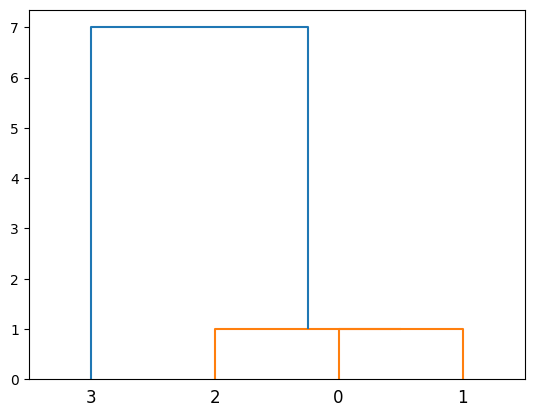

In [171]:
X = [[1],[2],[3],[10]]

Z = linkage(X)

dendrogram(Z)

plt.show()

## Ward's Linkage

Merge clusters causing minimum variance increase.
Produces compact clusters.



$$
\Delta ESS
=
ESS_{merged}
-
(ESS_1+ESS_2)
$$

## Single vs Complete Linkage

### Single Linkage

Uses nearest pair.

$$
d(A,B)=
\min d(a,b)
$$


### Complete Linkage

Uses farthest pair.

$$
d(A,B)=
\max d(a,b)
$$

## Average Linkage

Uses average pairwise distance. Balanced between single and complete.

$$
d(A,B)=
\frac1{|A||B|}
\sum d(a,b)
$$

## Minimum Spanning Tree Criterion

Connects all points with minimum total edge weight.

Used in graph-based clustering.

$$
MST=
\arg\min
\sum w(e)
$$

## DBSCAN Core Point Condition

Point must have enough neighbors.
Defines dense regions.

$$
|N_\epsilon(p)|
\ge
MinPts
$$

## DBSCAN Density Condition

Points connected through dense neighborhoods.
Builds clusters from density reachability.

$$
d(p,q)\le \epsilon
$$

## Cohesion Metric

Measures cluster compactness. Lower values are better.

$$
C=
\sum ||x-\mu||^2
$$

## Separation Metric

Distance between clusters. Higher values are better.

$$
S=
||\mu_i-\mu_j||
$$

## Soft Clustering Membership

Probability of belonging to a cluster.

Allows partial membership.

$$
\sum_j u_{ij}=1
$$

## Entropy for Clustering Evaluation

Measures cluster impurity. Lower entropy means purer clusters.

$$
H=
-\sum p_i\log p_i
$$

In [172]:
p = np.array([0.8,0.2])

entropy = -np.sum(p*np.log2(p))

print(entropy)

0.7219280948873623


## Mutual Information (MI)

Shared information between labels and clusters. Higher MI means better clustering.

$$
MI=
\sum p(x,y)
\log
\frac{p(x,y)}
{p(x)p(y)}
$$

## F-Measure for Clustering

 Harmonic mean of precision and recall.

Balances false positives and false negatives.

$$
F_1=
\frac{2PR}{P+R}
$$

In [173]:
y_true = [0,1,1,0]
y_pred = [0,1,0,0]

print(f1_score(y_true,y_pred))

0.6666666666666666


## Adjusted Rand Index (ARI)

Measures agreement between clustering and true labels.

Corrects for random chance.

$$
ARI=
\frac{RI-E(RI)}
{max(RI)-E(RI)}
$$

In [174]:
true = [0,0,1,1]
pred = [0,0,1,1]

print(adjusted_rand_score(true,pred))

1.0


## Normalized Mutual Information (NMI)

Normalized version of Mutual Information.

Produces values between 0 and 1.

$$
NMI=
\frac{2MI}
{H(X)+H(Y)}
$$

In [175]:
true = [0,0,1,1]
pred = [0,0,1,1]

print(normalized_mutual_info_score(true,pred))

1.0


# ***Chapter - 8 : Dimensionality Reduction***

## Principal Component Analysis (PCA)



Find directions (principal components) that maximize variance in data. Reduce dimensionality while preserving maximum information.


subject to ||w|| =1

Covariance Matrix

Measures feature relationships.

$$C = (1/(n-1)) XᵀX$$

In [176]:
X = np.array([[1,2],[3,4],[5,6]])
X = X - X.mean(axis=0)

C = np.cov(X.T)
print(C)

[[4. 4.]
 [4. 4.]]


## Eigen Decomposition

Principal components are eigenvectors of covariance matrix.

$$Cv = λv$$

In [177]:
eigvals, eigvecs = np.linalg.eig(C)
print(eigvals)
print(eigvecs)

[8. 0.]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## Reconstruction Error

Measures information lost after projection.

$$Error = ||X - X̂||²$$

In [178]:
n_components = 1
principal_components = eigvecs[:, :n_components]

X_transformed = X @ principal_components
X_hat = X_transformed @ principal_components.T

error = np.sum((X - X_hat)**2)
print(error)

7.888609052210118e-31


## Explained Variance Ratio

Fraction of total variance explained by each component.

$$EVR_i = λ_i / Σλ$$

In [179]:
evr = eigvals / np.sum(eigvals)
print(evr)

[1. 0.]


## Cumulative Explained Variance

Shows total variance captured by first k components.

$$CEV_k = Σ EVR_i$$

In [180]:
cev = np.cumsum(evr)
print(cev)

[1. 1.]


## Singular Value Decomposition (SVD)

Factorizes matrix into orthogonal matrices and singular values.

Used in PCA, compression, recommendation systems.

$$X = UΣVᵀ$$

In [181]:
U, S, VT = np.linalg.svd(X)
print(S)

[4. 0.]


## Random Projection

Projects data using a random matrix. Fast dimensionality reduction.

$$Y = XR$$

In [182]:
R = np.random.randn(X.shape[1], 2)
Y = X @ R
print(Y)

[[-2.26957637 -3.17010115]
 [ 0.          0.        ]
 [ 2.26957637  3.17010115]]


## Isomap Distance Matrix

Uses shortest-path distances on neighborhood graph.

Preserves manifold geometry.

$$
D_geo(i,j) = shortest path distance
$$

In [183]:
D = cdist(X, X)
print(D)

[[0.         2.82842712 5.65685425]
 [2.82842712 0.         2.82842712]
 [5.65685425 2.82842712 0.        ]]


## Multidimensional Scaling (MDS)

Embeds points preserving pairwise distances.

Distance-preserving visualization.

$$Stress = Σ(dij - δij)²$$

where,

$$dij = embedded distance$$

$$
δij = original distance$$

In [184]:
D_original = D

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
X_embedded = mds.fit_transform(D_original)
D_embed = cdist(X_embedded, X_embedded)

stress = np.sum((D_embed - D_original)**2)
print(stress)

0.05516493041538451


## Non-negative Matrix Factorization (NMF)

Factorizes non-negative matrix. Produces interpretable latent factors.

$$X ≈ WH$$

In [185]:
W = np.abs(np.random.rand(5,2))
H = np.abs(np.random.rand(2,4))
X_hat = W @ H

print(X_hat)

[[0.23500091 0.2088245  0.23314254 0.20582373]
 [0.29497945 0.23100416 0.29093191 0.16858383]
 [0.78957098 0.60238224 0.77785816 0.4052452 ]
 [0.92611497 0.79286498 0.91713304 0.72432051]
 [0.13860026 0.09920823 0.13618417 0.05228882]]


## Independent Component Analysis (ICA)

Find statistically independent components.
Useful for source separation.

$$X = AS$$

Find,

$$S = WX$$

In [186]:
X_centered = X - X.mean(axis=0)

print(X_centered)

[[-2. -2.]
 [ 0.  0.]
 [ 2.  2.]]


## Factor Analysis

Observed variables depend on hidden factors.

$$X = LF + ε$$

where,

$$L = loading matrix$$
$$F = latent factors$$
$$ε = noise$$

In [187]:
L = np.random.randn(4,2)
F = np.random.randn(2,5)
X = L @ F

print(X)

[[ 0.283769   -0.45677074 -0.41443185 -0.03161658  0.71840926]
 [-0.34146154 -0.33371577 -1.17633752  0.01857475  1.68669518]
 [ 0.27423545 -0.35768049 -0.24171076 -0.0287086   0.45241526]
 [ 0.65595913 -0.51043074  0.07627095 -0.06106288  0.0854188 ]]


## Kernel PCA

Transformation and Captures nonlinear structure.

$$Kij = k(xi,xj)$$

projection,

$$y = αᵀK$$

In [188]:
def rbf_kernel(X, gamma=1.0):
    sq_dists = np.sum((X[:, np.newaxis] - X[np.newaxis, :])**2, axis=2)
    return np.exp(-gamma * sq_dists)

X = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

K = rbf_kernel(X)

print(K)

[[1.00000000e+00 3.35462628e-04 1.26641655e-14]
 [3.35462628e-04 1.00000000e+00 3.35462628e-04]
 [1.26641655e-14 3.35462628e-04 1.00000000e+00]]


## Linear Discriminant Analysis (LDA) Fisher's Criterion


Maximize class separation.

$$J(w) = (wᵀSBw)/(wᵀSWw)$$

where,

$$SB = between-class scatter$$


$$SW = within-class scatter$$

In [189]:
X = np.array([[1, 2], [2, 3], [3, 3], [6, 7], [7, 8], [8, 8]])
y = np.array([0, 0, 0, 1, 1, 1])

# Class means
mean0 = np.mean(X[y == 0], axis=0)
mean1 = np.mean(X[y == 1], axis=0)

# Within-class scatter matrix (SW)
SW = np.zeros((X.shape[1], X.shape[1]))
for i in range(X.shape[0]):
    xi = X[i, :]
    if y[i] == 0:
        SW += np.outer((xi - mean0), (xi - mean0))
    else:
        SW += np.outer((xi - mean1), (xi - mean1))

# Between-class scatter matrix (SB)
SB = np.outer((mean0 - mean1), (mean0 - mean1))

# Eigenvalues and eigenvectors of inv(SW) @ SB
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(SW) @ SB)

# Select the eigenvector corresponding to the largest eigenvalue (this is w)
w = eigvecs[:, np.argmax(eigvals)]

score = (w.T @ SB @ w) / (w.T @ SW @ w)

print(score)

24.999999999999996


## Robust PCA (RPCA)

Separates low-rank structure and sparse noise. Works well with outliers.

$$X = L + S$$

where,

$$L = low rank$$
$$S = sparse matrix$$

## Hessian Locally Linear Embedding (Hessian LLE)


Nonlinear manifold learning using Hessian operator. Preserves local geometry.

$$min Σ ||yi - Σwijyj||²$$

## Laplacian Eigenmaps

Preserve local neighborhood structure.


$$min Σ Wij ||yi-yj||²$$

Subject to,

$$YᵀDY = I$$

In [190]:
# Example adjacency matrix W for a small graph (e.g., 3 nodes)
W = np.array([
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 0]
])

# Calculate the degree matrix D from W
D = np.diag(np.sum(W, axis=1))

# Calculate the Laplacian matrix L
L = D - W

# Calculate eigenvalues and eigenvectors of L
eigvals, eigvecs = np.linalg.eig(L)

print("Adjacency Matrix W:\n", W)
print("\nDegree Matrix D:\n", D)
print("\nLaplacian Matrix L:\n", L)
print("\nEigenvalues:\n", eigvals)
print("\nEigenvectors:\n", eigvecs)

Adjacency Matrix W:
 [[0 1 1]
 [1 0 0]
 [1 0 0]]

Degree Matrix D:
 [[2 0 0]
 [0 1 0]
 [0 0 1]]

Laplacian Matrix L:
 [[ 2 -1 -1]
 [-1  1  0]
 [-1  0  1]]

Eigenvalues:
 [ 3.00000000e+00 -2.91433544e-16  1.00000000e+00]

Eigenvectors:
 [[-8.16496581e-01  5.77350269e-01  1.57009246e-16]
 [ 4.08248290e-01  5.77350269e-01 -7.07106781e-01]
 [ 4.08248290e-01  5.77350269e-01  7.07106781e-01]]


## Autoencoder

Learn compressed representation and reconstruct input.

$$x̂ = Decoder(Encoder(x))$$

loss,

$$L = ||x - x̂||²$$

In [191]:
x = np.array([1.0, 2.0, 3.0, 4.0])

# Example reconstructed input (output of the decoder)
x_hat = np.array([1.1, 1.9, 3.2, 4.3])

# Calculate the Mean Squared Error loss
loss = np.mean((x - x_hat)**2)

print("Original input (x):", x)
print("Reconstructed input (x_hat):", x_hat)
print("Autoencoder Loss (MSE):", loss)

Original input (x): [1. 2. 3. 4.]
Reconstructed input (x_hat): [1.1 1.9 3.2 4.3]
Autoencoder Loss (MSE): 0.037500000000000006


## Latent Representation


Compressed feature representation.

$$z = Encoder(x)$$

In [192]:
# Assume x is the input feature vector from the Autoencoder example (shape (4,))
x = np.array([1.0, 2.0, 3.0, 4.0])

# Define a random weight matrix W for the encoder.
# If x has 4 features, and we want a latent representation z with 2 dimensions,
# then W should have shape (4, 2).

latent_dim = 2
W = np.random.rand(x.shape[0], latent_dim)

# Calculate the latent representation z
z = np.dot(x, W)

print("Input x (features):", x)
print("Encoder Weights W:\n", W)
print("Latent Representation z:\n", z)

Input x (features): [1. 2. 3. 4.]
Encoder Weights W:
 [[0.12068795 0.51409207]
 [0.28873383 0.21896788]
 [0.36586203 0.72862281]
 [0.40189065 0.01794161]]
Latent Representation z:
 [3.40330429 3.2096627 ]


## Sparse PCA

Sparse principal components improve interpretability.

$$max Var(Xw) - λ||w||₁$$

In [193]:
l1_penalty = np.sum(np.abs(w))

print(l1_penalty)

1.2649110640673515


## t-SNE

Preserve local neighborhoods for visualization.

$$KL(P || Q)
=
Σ pij log(pij/qij)$$

In [194]:
P = np.array([0.1, 0.2, 0.7])
Q = np.array([0.2, 0.3, 0.5])

kl = np.sum(P * np.log(P / Q))

print(kl)

0.08512282595722162


## Gradient of t-SNE

Moves nearby points together and distant points apart.

$$∂C/∂yi
=
4 Σ (pij-qij)(yi-yj)(1+||yi-yj||²)^(-1)$$

## UMAP

Uniform Manifold Approximation and Projection. Preserves local and global structure better than t-SNE and scales faster.


### Objective

#### High-dimensional graph:

$$Pij$$

#### Low-dimensional graph:

$$Qij$$

### Loss:

$$L
=
Σ Pij log(Qij)
+
(1-Pij)log(1-Qij)$$


### Simple Idea :
1. Build nearest-neighbor graph
2. Estimate manifold structure
3. Optimize low-dimensional embedding

In [195]:
X = load_iris().data
embedding = umap.UMAP().fit_transform(X)

print(embedding.shape)

(150, 2)


# ***Chapter - 9 : Probability***

## Bernoulli (Discrete)


Single binary trial: 1 with prob p, 0 with prob 1−p. Foundation of all classification in ML.

#### Why it matters in ML?


Every logistic regression output node, every coin flip, every yes/no label is Bernoulli.

$$PMF: P(X=k) = p^k · (1−p)^(1−k),  k ∈ {0,1}$$
$$Mean: p   |   Variance: p(1−p)$$

In [196]:
# Parameters
p = 0.7
n_samples = 10000

# Sample
X = np.random.binomial(1, p, n_samples)
print("Mean:", X.mean(), "  Expected:", p)

Mean: 0.7052   Expected: 0.7


## Binomial (Discrete)

Number of successes in n independent Bernoulli trials. Generalises Bernoulli.



#### Why it matters in ML ?

Modelling counts of positive outcomes; approximated by Poisson for large n, small p.


Parameters

$$n ∈ ℕ (trials)$$
$$p ∈ [0,1]$$


Equations :

$$PMF: P(X=k) = C(n,k) · p^k · (1−p)^(n−k)$$

$$Mean: np   |   Variance: np(1−p)$$


$$P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$$



In [197]:
n, p = 10, 0.3
samples = np.random.binomial(n, p, 10000)
print("Mean:", samples.mean(), "  Expected:", n*p)

Mean: 2.9922   Expected: 3.0


## Poisson (Discrete)


Count of events in a fixed interval when events occur at constant average rate λ.



#### Why it matters in ML ?


NLP word counts, click rates, arrival queues, rare-event modelling.


Parameters :


$$λ > 0 (rate)$$

$$PMF: P(X=k) = e^(−λ) · λ^k / k!$$

$$Mean: λ   |   Variance: λ$$

$$P(X=k) = \frac{e^{-\lambda}\lambda^k}{k!}$$




In [198]:
lam = 4.0
samples = np.random.poisson(lam, 10000)
print("Mean:", samples.mean(), "  Expected:", lam)

Mean: 4.0338   Expected: 4.0


## Uniform (continuous)

Equal probability density over [a,b]. 'Knowing nothing' prior.

#### Why it matters in ML ?

Weight initialisation (Xavier), random search hyperparameter tuning, Monte Carlo.


Parameters :

$$a (lower)$$

$$b (upper)$$


$$PDF: f(x) = 1/(b−a)  for x ∈ [a,b]$$

$$Mean: (a+b)/2   |   Variance: (b−a)²/12$$

$$f(x) = \frac{1}{b-a}, \quad x \in [a,b]$$


In [199]:
a, b = 2.0, 8.0
samples = np.random.uniform(a, b, 10000)
print("Mean:", samples.mean().round(3), "  Expected:", (a+b)/2)

Mean: 4.998   Expected: 5.0


## Discrete Uniform (Discrete)

Equal probability 1/n across n distinct integer values. Fair dice.

#### Why it matters in ML ?

Categorical random sampling, random data splits, Monte Carlo baseline.


Parameters :

$$low$$

$$high (exclusive)$$

$$PMF: P(X=k) = 1/n   for k ∈ {low,...,high−1}$$
$$Mean: (low+high−1)/2$$

$$P(X=k) = \frac{1}{n}$$

In [200]:
samples = np.random.randint(1, 7, 10000)  # fair die
print("Mean:", samples.mean().round(3), "  Expected:", 3.5)

Mean: 3.516   Expected: 3.5


## Normal / Gaussian (Continuous)

Bell curve defined by mean μ and std σ. Central Limit Theorem: sums converge here.

#### Why it matters in ML ?

Assumed noise in linear regression, weight initialisation, latent space of VAEs.


Parameters :
$$μ (mean)$$

$$σ > 0 (std)$$


$$PDF: f(x) = (1/σ√2π) · exp(−(x−μ)²/2σ²)$$

$$Mean: μ   |   Variance: σ²$$

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

In [201]:
mu, sigma = 0.0, 1.0
samples = np.random.normal(mu, sigma, 10000)
print("Mean:", samples.mean().round(3), "  Std:", samples.std().round(3))

Mean: 0.004   Std: 0.994


## Exponential (Continuous)

Time until first event in a Poisson process. Memoryless continuous distribution.

#### Why it matters in ML ?

Modelling inter-arrival times, survival analysis, attention decay.


Parameters :     

$$λ > 0 (rate)$$

$$PDF: f(x) = λ·e^(−λx)  for x ≥ 0$$
$$Mean: 1/λ   |   Variance: 1/λ²$$

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

In [202]:
lam = 0.5
samples = np.random.exponential(scale=1/lam, size=10000)
print("Mean:", samples.mean().round(3), "  Expected:", 1/lam)

Mean: 1.982   Expected: 2.0


## Geometric (Discrete)

Number of Bernoulli trials until the first success. Discrete memoryless.

#### Why it matters in ML ?

Modelling number of attempts before success; RL episode lengths.

Parameters :    

$$p ∈ (0,1]$$

$$PMF: P(X=k) = (1−p)^(k−1) · p   k = 1,2,3,...$$


$$Mean: 1/p   |   Variance: (1−p)/p²$$

$$P(X=k) = (1-p)^{k-1}p$$

In [203]:
p = 0.25
samples = np.random.geometric(p, 10000)
print("Mean:", samples.mean().round(3), "  Expected:", 1/p)

Mean: 3.974   Expected: 4.0


## Hypergeometric (Discrete)

Successes in n draws WITHOUT replacement from a finite population. Like binomial but no replacement.

#### Why it matters in ML ?

Evaluating classification precision; sampling without replacement.


Parameters :     


$$N (pop)$$

$$K (success in pop)$$

$$n (draws)$$


$$PMF: P(X=k) = C(K,k)·C(N−K,n−k) / C(N,n)$$

$$Mean: n·K/N$$

$$P(X=k) = \frac{\binom{K}{k}\binom{N-K}{n-k}}{\binom{N}{n}}$$

In [204]:
N, K, n = 52, 13, 5  # hearts in a 5-card hand
samples = np.random.hypergeometric(K, N-K, n, 10000)
print("Mean:", samples.mean().round(3), "  Expected:", n*K/N)

Mean: 1.246   Expected: 1.25


## Beta (Continuous)

Distribution over probabilities [0,1]. Conjugate prior to Binomial.

#### Why it matters in ML ?

Bayesian A/B testing; Thompson sampling; modelling uncertainty in probabilities.


Parameters :    


$$α > 0$$

$$β > 0$$

$$PDF: f(x) = x^(α−1)·(1−x)^(β−1) / B(α,β)  x ∈ [0,1]$$

$$Mean: α/(α+β)   |   Var: αβ/((α+β)²(α+β+1))$$

$$f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}$$

In [205]:
a, b = 2.0, 5.0
samples = np.random.beta(a, b, 10000)
print("Mean:", samples.mean().round(3), "  Expected:", a/(a+b))

Mean: 0.289   Expected: 0.2857142857142857


## Gamma (Continuous)

Sum of k independent Exponential variables. Flexible positive-valued distribution.

#### Why it matters in ML ?


Conjugate prior to Poisson rate; Bayesian regression; modelling waiting times.


Parameters :  


$$k > 0 (shape)$$

$$θ > 0 (scale)$$

$$Equations (plain)$$

$$PDF: f(x) = x^(k−1)·e^(−x/θ) / (θ^k·Γ(k))  x > 0$$
$$Mean: kθ   |   Variance: kθ²$$

$$f(x) = \frac{x^{k-1}e^{-x/\theta}}{\theta^k\Gamma(k)}$$

In [206]:
k, theta = 3.0, 2.0
samples = np.random.gamma(k, theta, 10000)
print("Mean:", samples.mean().round(3), "  Expected:", k*theta)

Mean: 5.893   Expected: 6.0


## Multinomial (Discrete)

Generalisation of Binomial to k categories. n trials, each falling into one of k buckets.

#### Why it matters in ML ?


Language model output probabilities; class frequency modelling; topic models.


Parameters :    

$$n (trials)$$

$$p: vector summing to 1$$

$$PMF: P(x₁,…,xₖ) = n!/(x₁!…xₖ!) · p₁^x₁·…·pₖ^xₖ$$

$$Mean of xᵢ: n·pᵢ$$

$$P(x_1,\ldots,x_k) = \frac{n!}{x_1!\cdots x_k!}\prod_i p_i^{x_i}$$

In [207]:
n = 20
probs = [0.2, 0.3, 0.5]
samples = np.random.multinomial(n, probs, 10000)
print("Means:", samples.mean(axis=0).round(2), "  Expected:", np.array(probs)*n)

Means: [ 4.    5.99 10.01]   Expected: [ 4.  6. 10.]


## Chi-squared (Continuous)

Sum of squares of k independent standard Normal variables. Special case of Gamma.

#### Why it matters in ML ?


Hypothesis tests; feature selection (chi-square test); goodness-of-fit.


Parameters :     

$$k > 0 (degrees of freedom)$$

$$PDF: f(x) = x^(k/2−1)·e^(−x/2) / (2^(k/2)·Γ(k/2))  x > 0$$
$$Mean: k   |   Variance: 2k$$

$$f(x) = \frac{x^{k/2-1}e^{-x/2}}{2^{k/2}\Gamma(k/2)}$$

In [208]:
k = 5
samples = np.random.chisquare(k, 10000)
print("Mean:", samples.mean().round(3), "  Expected:", k)

Mean: 4.957   Expected: 5


## Student's t (Continuous)



Like Normal but with heavier tails. Arises when population variance is unknown.

#### Why it matters in ML ?

Small-sample hypothesis testing; robust regression (fat tails reduce outlier sensitivity).

Parameters :     

$$ν > 0 (degrees of freedom)$$

$$PDF: f(x) = Γ((ν+1)/2) / (√(νπ)·Γ(ν/2)) · (1 + x²/ν)^(−(ν+1)/2)$$
$$Mean: 0 (ν>1)   |   Var: ν/(ν−2) (ν>2)$$

$$f(x) = \frac{\Gamma(\frac{\nu+1}{2})}{\sqrt{\nu\pi}\,\Gamma(\frac{\nu}{2})}\left(1+\frac{x^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

In [209]:
nu = 5
samples = stats.t.rvs(nu, size=10000)
print("Mean:", samples.mean().round(3), "  Std:", samples.std().round(3))

Mean: -0.003   Std: 1.265


## F Distribution (Continuous)

Ratio of two chi-squared variables divided by their degrees of freedom.

#### Why it matters in ML ?

ANOVA F-test; comparing model variances; feature importance tests.


Parameters :    


$$d₁ > 0$$
$$d₂ > 0 (df numerator, denominator)$$

$$PDF: f(x) = √((d₁x)^d₁ · d₂^d₂ / (d₁x+d₂)^(d₁+d₂)) / (x·B(d₁/2,d₂/2))$$

$$Mean: d₂/(d₂−2) for d₂ > 2$$

$$f(x) = \frac{\sqrt{\frac{(d_1 x)^{d_1}d_2^{d_2}}{(d_1 x+d_2)^{d_1+d_2}}}}{x\,B(d_1/2,\,d_2/2)}$$

In [210]:
d1, d2 = 5, 10
samples = stats.f.rvs(d1, d2, size=10000)
print("Mean:", samples.mean().round(3), "  Expected:", d2/(d2-2))



Mean: 1.233   Expected: 1.25


## Laplace (Continuous)

Double-sided exponential. Heavier tails than Gaussian. L1-norm equivalent.

#### Why it matters in ML ?

Equivalent to L1 (Lasso) regularisation; sparse signal modelling; robust regression.

Parameters :    

$$μ (location)$$

$$b > 0 (scale)$$

$$PDF: f(x) = (1/2b) · exp(−|x−μ|/b)$$

$$Mean: μ   |   Variance: 2b²$$

$$f(x) = \frac{1}{2b}e^{-|x-\mu|/b}$$

In [211]:
mu, b = 0.0, 1.0
samples = np.random.laplace(mu, b, 10000)
print("Mean:", samples.mean().round(3), "  Var:", samples.var().round(3))

Mean: 0.015   Var: 2.006


## Rayleigh (Continuous)

Distribution of the magnitude of a 2D vector with independent Normal components.

#### Why it matters in ML ?

Signal processing (Rayleigh fading); wind speed modelling; 2D distance distributions.


Parameters :


$$σ > 0 (scale)$$

$$PDF: f(x) = (x/σ²) · exp(−x²/(2σ²))  x ≥ 0$$

$$Mean: σ√(π/2)   |   Variance: (4−π)σ²/2$$

$$f(x) = \frac{x}{\sigma^2}e^{-x^2/(2\sigma^2)},\quad x\geq 0$$

In [212]:
sigma = 2.0
samples = stats.rayleigh.rvs(scale=sigma, size=10000)
print("Mean:", samples.mean().round(3), "  Expected:", sigma*(3.14159/2)**0.5)

Mean: 2.51   Expected: 2.5066272160016134


## Triangular (Continuous)

Linear rise then fall between a and b, peaking at mode c. Simple bounded distribution.



#### Why it matters in ML ?

Simple project time estimation (PERT); simulation when only min/max/mode are known.


Parameters :    

$$a (min)$$

$$b (max)$$

$$c (mode)$$

$$PDF: f(x) = 2(x−a)/((b−a)(c−a))  for a≤x≤c
       f(x) = 2(b−x)/((b−a)(b−c))  for c$$
    


    
$$f(x) = \begin{cases}\frac{2(x-a)}{(b-a)(c-a)} & a\le x\le c\\ \frac{2(b-x)}{(b-a)(b-c)} & c < x \le b\end{cases}$$

In [213]:
a, c_mode, b = 1.0, 4.0, 9.0
# numpy uses c as (mode-a)/(b-a)
c_np = (c_mode - a) / (b - a)
samples = np.random.triangular(a, c_mode, b, 10000)
print("Mean:", samples.mean().round(3), "  Expected:", (a+b+c_mode)/3)

Mean: 4.656   Expected: 4.666666666666667


## Log-Normal (Continuous )

If ln(X) ~ Normal, then X is log-normal. Always positive, right-skewed.

#### Why it matters in ML ?

Stock prices, income distributions, file sizes, biological measurements.

Parameters :    

$$μ (log-mean)$$

$$σ > 0 (log-std)$$

$$PDF: f(x) = exp(−(ln x−μ)²/2σ²) / (xσ√2π)  x > 0$$

$$Mean: exp(μ + σ²/2)   |   Var: (e^σ²−1)·e^(2μ+σ²)$$

$$f(x) = \frac{e^{-(\ln x - \mu)^2/2\sigma^2}}{x\sigma\sqrt{2\pi}}$$

In [214]:
mu, sigma = 0.0, 0.5
samples = np.random.lognormal(mu, sigma, 10000)
import math
print("Mean:", samples.mean().round(3), "  Expected:", round(math.exp(mu + sigma**2/2),3))

Mean: 1.137   Expected: 1.133


## Arcsine (Continuous)

U-shaped: probability mass at the extremes of [0,1]. Special case of Beta(½,½).

#### Why it matters in ML ?

Random walk return times; fair coin run lengths; signal processing.

Parameters :     none (standard form on [0,1])

$$PDF: f(x) = 1 / (π√(x(1−x)))  x ∈ (0,1)$$

$$Mean: 1/2   |   Variance: 1/8$$


$$f(x) = \frac{1}{\pi\sqrt{x(1-x)}},\quad x\in(0,1)$$

In [215]:
# Arcsine = Beta(0.5, 0.5)
samples = np.random.beta(0.5, 0.5, 10000)
print("Mean:", samples.mean().round(3), "  Expected: 0.5")

Mean: 0.496   Expected: 0.5


## Beta-Binomial ( Discrete )

Binomial where p is itself Beta-distributed. Overdispersed count model.


#### Why it matters in ML ?

Modelling variable success rates (e.g., click-through rates across users).

Parameters :     

$$n (trials)$$

$$α > 0$$

$$β > 0$$


$$PMF: P(X=k) = C(n,k) · B(k+α, n−k+β) / B(α,β)$$

$$Mean: nα/(α+β)$$

$$P(X=k) = \binom{n}{k}\frac{B(k+\alpha,\,n-k+\beta)}{B(\alpha,\beta)}$$





In [216]:
n, a, b = 20, 2.0, 5.0
# scipy uses n, a, b
samples = stats.betabinom.rvs(n, a, b, size=10000)
print("Mean:", samples.mean().round(3), "  Expected:", round(n*a/(a+b),3))

Mean: 5.644   Expected: 5.714


## Cauchy (Continuous)

Ratio of two independent standard Normals. Undefined mean and variance — extreme tails.

#### Why it matters in ML ?

Robustness testing; stable distribution; Lorentzian spectral lines in physics.

Parameters :   

$$x₀ (location)$$
$$γ > 0 (scale)$$

$$PDF: f(x) = 1 / (πγ·(1 + ((x−x₀)/γ)²))$$
$$Mean: undefined   |   Variance: undefined$$

$$f(x) = \frac{1}{\pi\gamma\left[1+\left(\frac{x-x_0}{\gamma}\right)^2\right]}$$

In [217]:
x0, gamma = 0.0, 1.0
samples = stats.cauchy.rvs(loc=x0, scale=gamma, size=10000)
print("Median:", np.median(samples).round(3), "  (mean undefined)")

Median: 0.002   (mean undefined)


## Weibull Continuous

Flexible lifetime distribution. Shape k controls whether failure rate increases/decreases.

#### Why it matters in ML ?

Survival analysis; hardware failure modelling; wind energy; anomaly detection.


Parameters :   

$$k > 0 (shape)$$

$$λ > 0 (scale)$$

$$PDF: f(x) = (k/λ)·(x/λ)^(k−1)·exp(−(x/λ)^k)  x ≥ 0$$

$$Mean: λ·Γ(1 + 1/k)$$

$$f(x) = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1}e^{-(x/\lambda)^k}$$

In [218]:
k, lam = 1.5, 2.0
# numpy weibull gives shape only; scale by lam
samples = lam * np.random.weibull(k, 10000)
import math
print("Mean:", samples.mean().round(3), "  Expected:", round(lam*math.gamma(1+1/k),3))

Mean: 1.788   Expected: 1.805


## Pareto (Continuous)

Power-law tail. The 80/20 rule lives here. Heavy right tail.

#### Why it matters in ML ?

Wealth distribution, file sizes, citation counts, network degree distribution.

Parameters :   

$$xₘ > 0 (min value)$$

$$α > 0 (shape)$$



$$PDF: f(x) = α·xₘ^α / x^(α+1)  for x ≥ xₘ$$

$$Mean: α·xₘ/(α−1) for α>1   |   Var: xₘ²α/((α−1)²(α−2)) for α>2$$



$$f(x) = \frac{\alpha x_m^\alpha}{x^{\alpha+1}},\quad x \geq x_m$$

In [219]:
alpha, xm = 3.0, 1.0
samples = (np.random.pareto(alpha, 10000) + 1) * xm
print("Mean:", samples.mean().round(3), "  Expected:", round(alpha*xm/(alpha-1),3))

Mean: 1.506   Expected: 1.5


## Log-Cauchy (Continuous)

If ln(X) ~ Cauchy, then X is log-Cauchy. Extremely heavy tails — heavier than log-normal.

#### Why it matters in ML ?

Ultra-rare catastrophic events; very heavy-tailed financial returns.

Parameters :   

$$μ (location)$$

$$σ > 0 (scale)$$



$$PDF: f(x) = 1 / (xσπ·(1 + ((ln x − μ)/σ)²))  x > 0$$

$$Mean: undefined   |   Variance: undefined$$



$$f(x) = \frac{1}{x\sigma\pi\left[1+\left(\frac{\ln x - \mu}{\sigma}\right)^2\right]}$$





In [220]:
mu, sigma = 0.0, 1.0
# Log-Cauchy: exp of Cauchy samples
cauchy_s = stats.cauchy.rvs(loc=mu, scale=sigma, size=10000)
samples = np.exp(cauchy_s)
print("Median:", np.median(samples).round(3), "  (mean undefined)")

Median: 0.994   (mean undefined)


/tmp/ipykernel_8836/291996091.py:4: RuntimeWarning: overflow encountered in exp
  samples = np.exp(cauchy_s)


## Law of Large Numbers (LLN)


Sample average converges to the true expected value as sample size increases.



Justifies estimating population parameters from data.

Formula ::
$$(1/n) Σ Xᵢ → E[X]$$

In [221]:
samples = np.random.normal(0, 1, 10000)

print(np.mean(samples))

-0.001876219569878203


## Central Limit Theorem (CLT)

Sample means tend toward a normal distribution.


Explains why Gaussian assumptions appear frequently.

Formula :

$$(X̄ - μ)/(σ/√n) → N(0,1)$$

In [222]:
means = []

for _ in range(1000):
    sample = np.random.uniform(0, 1, 30)
    means.append(np.mean(sample))

print(np.mean(means))

0.5007478521791769


## Moment Generating Function (MGF)

Generates moments of a random variable.


Useful for deriving mean and variance.

Formula :

$$M_X(t) = E[e^(tX)]$$

In [223]:
X = np.array([1, 2, 3])

t = 0.5

mgf = np.mean(np.exp(t * X))

print(mgf)

2.9495640564990793


# ***Chapter - 10 : Reinforcement Learning***

## Reward Function


Defines the immediate feedback received after taking an action.


The agent learns to maximize cumulative rewards, so rewards define the goal.

Formula :     

$$R(s,a)$$
$$or$$
$$r_t = R(s_t,a_t)$$

In [224]:
reward = 10
print(reward)

10


## Discounted Return


Total future reward discounted over time.

Future rewards are usually less valuable than immediate rewards.

Formula :    

$$G_t = r_t + γr_{t+1} + γ²r_{t+2} + ...$$


In [225]:
rewards = np.array([1, 2, 3])
gamma = 0.9

G = sum((gamma**i) * rewards[i] for i in range(len(rewards)))
print(G)

5.23


## Bellman Equation (State Value Function)


Defines value of a state under policy π.


Current value equals immediate reward plus expected future value.

Formula :    

$$V(s) = E[r + γV(s')]$$

In [226]:
reward = 5
gamma = 0.9
next_value = 10

V = reward + gamma * next_value
print(V)

14.0


## Bellman Equation (Action Value Function)

Defines value of taking action a in state s.

Measures long-term usefulness of an action.

Formula  :      

$$Q(s,a) = E[r + γ max_a' Q(s',a')]$$

In [227]:
reward = 5
gamma = 0.9
next_q = np.max([10, 8, 12])

Q = reward + gamma * next_q
print(Q)

15.8


## Temporal Difference (TD) Update

Updates value estimates using bootstrapping.

Learns before an episode finishes.

Formula :

$$V(s) ← V(s) + α[r + γV(s') - V(s)]$$

In [228]:
V = 5
alpha = 0.1
reward = 2
gamma = 0.9
next_V = 8

V = V + alpha * (reward + gamma * next_V - V)
print(V)

5.42


## Monte Carlo Policy Update

Updates policy using complete episode returns.

Uses actual returns instead of estimates.

Formula :    

$$V(s) ← average(G_t)$$

In [229]:
returns = np.array([10, 12, 8])
V = np.mean(returns)
print(V)

10.0


## Policy Improvement

Improves policy by choosing best actions.

Greedy actions lead to better performance.

Formula :     


$$π'(s) = argmax_a Q(s,a)$$

In [230]:
Q = np.array([5, 10, 7])

best_action = np.argmax(Q)
print(best_action)

1


## Q-Learning Update

Off-policy TD control algorithm.

Learns optimal policy regardless of behavior policy.

Formula  :     


$$Q(s,a) ← Q(s,a) + α[r + γ max_a'Q(s',a') - Q(s,a)]$$

In [231]:
Q = 5
alpha = 0.1
reward = 2
gamma = 0.9
next_Q = np.max([4, 8, 6])

Q = Q + alpha * (reward + gamma * next_Q - Q)
print(Q)

5.42


## SARSA Update

On-policy TD control method.

Uses action actually chosen by policy.

Formula :     

$$Q(s,a) ← Q(s,a) + α[r + γQ(s',a') - Q(s,a)]$$

In [232]:
Q = 5
alpha = 0.1
reward = 2
gamma = 0.9
next_Q = 7

Q = Q + alpha * (reward + gamma * next_Q - Q)
print(Q)

5.33


## Value Iteration Update


Computes optimal value function.

Repeated Bellman optimality updates converge to optimum.

Formula :     

$$V(s) ← max_a [r + γV(s')]$$

In [233]:
reward = 2
gamma = 0.9
next_values = np.array([5, 7, 4])

V = np.max(reward + gamma * next_values)
print(V)

8.3


## Actor-Critic Policy Update

Actor updates policy, critic estimates value.

Reduces variance compared to pure policy gradient.

Formula :     

$$θ ← θ + α δ ∇θ log π(a|s)$$

In [234]:
theta = 1.0
alpha = 0.01
td_error = 2.0
grad = 0.5

theta += alpha * td_error * grad
print(theta)

1.01


## Deterministic Policy Gradient


Policy outputs deterministic actions.

Useful for continuous action spaces.

Formula :    


$$∇J = E[∇aQ(s,a) ∇θμ(s)]$$

In [235]:
grad_Q = 0.8
grad_policy = 0.4

gradient = grad_Q * grad_policy
print(gradient)

0.32000000000000006


## Discount Factor

Controls importance of future rewards.

Higher γ values encourage long-term planning.

Formula :     

$$0 ≤ γ ≤ 1$$

In [236]:
gamma = 0.99
print(gamma)

0.99


## Expected SARSA

Uses expected future Q-values.

Less variance than SARSA.

Formula :    

$$Q ← Q + α[r + γ Σ π(a|s')Q(s',a) - Q]$$

In [237]:
q_values = np.array([5, 7])
probs = np.array([0.6, 0.4])

expected_q = np.sum(probs * q_values)
print(expected_q)

5.800000000000001


## Eligibility Traces Update


Assigns credit to recently visited states.


Combines TD and Monte Carlo ideas.

Formula :    

$$e_t = γλe_{t-1} + 1$$

In [238]:
gamma = 0.9
lam = 0.8
e = 0

e = gamma * lam * e + 1
print(e)

1.0


## TD Error


Difference between prediction and target.

Drives learning updates.

Formula :     

$$δ = r + γV(s') - V(s)$$

In [239]:
reward = 2
gamma = 0.9
next_V = 8
V = 5

delta = reward + gamma * next_V - V
print(delta)

4.199999999999999


## SGD in RL

Updates parameters using gradient estimates.


Optimizes value functions and policies.

Formula :
$$θ ← θ - α∇L(θ)$$

In [240]:
theta = 5
alpha = 0.01
grad = 2

theta -= alpha * grad
print(theta)

4.98


## Double Q-Learning

Uses two Q tables.


Reduces overestimation bias.

Formula :   
$$Q₁ ← r + γQ₂(argmax(Q₁))$$

In [241]:
Q1 = np.array([5, 8])
Q2 = np.array([6, 7])

action = np.argmax(Q1)
target = Q2[action]

print(target)

7


## Advantage Actor-Critic (A2C)


Uses advantage instead of raw return.


Reduces variance and stabilizes learning.

Formula :
$$A(s,a) = Q(s,a) - V(s)$$

In [242]:
Q = 10
V = 7

advantage = Q - V
print(advantage)

3


## Off-Policy Evaluation

Evaluates target policy using behavior-policy data.


Allows learning from old experiences.

Formula :

$$ρ = π(a|s) / b(a|s)$$

In [243]:
pi = 0.7
b = 0.5

rho = pi / b
print(rho)

1.4


## Policy Gradient Update Rule

Directly optimizes policy parameters.


Suitable for continuous and stochastic actions.

Formula :

$$θ ← θ + αG_t ∇θ log π(a|s)$$

In [244]:
theta = 1
alpha = 0.01
G = 10
grad = 0.3

theta += alpha * G * grad
print(theta)

1.03


## Soft Q-Learning Objective

Adds entropy bonus to Q-learning.


Encourages exploration.

Formula :    

$$Q = r + γ(V + αH)$$

In [245]:
reward = 2
gamma = 0.9
V = 8
entropy = 0.5
alpha = 0.2

Q = reward + gamma * (V + alpha * entropy)
print(Q)

9.29


## Entropy-Regularized RL

Maximizes reward and policy entropy.

Prevents premature convergence.

Formula :

$$J = E[R + αH(π)]$$

In [246]:
reward = 10
entropy = 0.8
alpha = 0.2

objective = reward + alpha * entropy
print(objective)

10.16


## Soft Actor-Critic (SAC)

Actor-Critic algorithm with entropy maximization.


Provides stable learning and strong exploration.

Formula :


$$J = E[Q(s,a) - α log π(a|s)]$$

In [247]:
Q = 10
alpha = 0.2
log_prob = -1

objective = Q - alpha * log_prob
print(objective)

10.2


## Trust Region Policy Optimization (TRPO)

Policy gradient method with constrained updates.


Prevents large unstable policy changes.

Formula :    

$$maximize E[(π_new/π_old)A]$$
$$subject to KL(π_old || π_new) ≤ δ$$

In [248]:
ratio = 1.1
advantage = 2

objective = ratio * advantage
print(objective)

2.2


| Concept | Core Idea |
|----------|----------|
| Reward | Immediate feedback |
| Return | Sum of future rewards |
| Bellman | Recursive value estimate |
| TD | Learn from next prediction |
| Monte Carlo | Learn from full episode |
| Q-Learning | Off-policy control |
| SARSA | On-policy control |
| A2C | Actor + Advantage |
| SAC | Actor-Critic + Entropy |
| TRPO | Constrained policy updates |
| DPG | Continuous deterministic actions |
| Double Q | Reduce overestimation |
| Eligibility Trace | Credit assignment over time |

# ***End Notes***

## ML Complexity

| Algorithm | Time Complexity |
|------------|----------------|
| Linear Regression (Normal Equation) | O(nd² + d³) |
| Linear Regression (Gradient Descent) | O(nd) per iteration |
| Logistic Regression | O(nd) per iteration |
| K-Means | O(nkd) per iteration |
| Hierarchical Clustering | O(n²) |
| DBSCAN | O(n log n) |
| PCA (Covariance + Eigen) | O(d³) |
| PCA (SVD) | O(nd²) |
| Decision Tree | O(nd log n) |
| Random Forest | O(Tnd log n) |
| Gradient Boosting | O(Tnd) |
| Neural Network | O(parameters) per forward/backward pass |

## Activation Function Usage

| Activation Function | When to Use |
|--------------------|-------------|
| Sigmoid | Binary classification output |
| Tanh | Hidden layers (rare today) |
| ReLU | Default hidden layer activation |
| Leaky ReLU | Avoid dead neurons |
| ELU | Faster convergence |
| GELU | Transformers and modern deep learning |
| Softmax | Multi-class classification output |

## Distribution Summary Table

| Distribution | Typical Use Case |
|-------------|------------------|
| Bernoulli | Single success/failure trial |
| Binomial | Number of successes in n trials |
| Poisson | Count of events |
| Uniform | Equal probability outcomes |
| Normal | Natural measurements |
| Exponential | Waiting times |
| Gamma | Positive skewed variables |
| Beta | Modeling probabilities |
| Student's t | Small sample statistics |
| F Distribution | ANOVA and variance comparison |
| Laplace | Robust modeling |
| Rayleigh | Signal processing |
| Log-Normal | Income, stock prices |
| Cauchy | Heavy-tailed data |
| Weibull | Reliability analysis |
| Pareto | Wealth distribution |

## Optimization Methods Summary

| Optimizer | Key Idea |
|------------|----------|
| Gradient Descent | Full dataset gradient |
| SGD | One sample gradient |
| Mini-Batch GD | Small batch gradient |
| Momentum | Velocity-based updates |
| Nesterov Momentum | Look-ahead momentum |
| AdaGrad | Adaptive learning rates |
| RMSProp | Exponential moving average |
| Adam | Momentum + RMSProp |
| AdamW | Adam with decoupled weight decay |


## Neural Network Components Summary

| Component | Purpose |
|-----------|---------|
| Dense Layer | Fully connected transformation |
| Batch Normalization | Stabilize training |
| Layer Normalization | Normalize features |
| Dropout | Reduce overfitting |
| Residual Connection | Easier gradient flow |
| Attention | Learn important relationships |
| Multi-Head Attention | Multiple attention mechanisms |
| Positional Encoding | Preserve sequence order |

## Loss Function Summary

| Loss Function | Use Case |
|--------------|----------|
| MSE | Regression |
| MAE | Robust regression |
| Huber Loss | Regression with outliers |
| Binary Cross Entropy | Binary classification |
| Categorical Cross Entropy | Multi-class classification |
| Hinge Loss | SVM |
| KL Divergence | Distribution comparison |
| Focal Loss | Imbalanced classification |

## Reinforcement Learning Summary

| Concept | Core Idea |
|----------|----------|
| Reward | Immediate feedback |
| Return | Sum of future rewards |
| Bellman | Recursive value estimate |
| TD | Learn from next prediction |
| Monte Carlo | Learn from full episode |
| Q-Learning | Off-policy control |
| SARSA | On-policy control |
| A2C | Actor + Advantage |
| SAC | Actor-Critic + Entropy |
| TRPO | Constrained policy updates |
| DPG | Continuous deterministic actions |
| Double Q | Reduce overestimation |
| Eligibility Trace | Credit assignment over time |

## Linear Algebra Quick Revision

| Concept | Formula |
|----------|---------|
| Dot Product | aᵀb |
| Matrix Multiplication | AB |
| Matrix Inverse | A⁻¹ |
| Determinant | det(A) |
| Rank | rank(A) |
| Eigenvalue Equation | Av = λv |
| Covariance Matrix | Σ = (1/n)XᵀX |
| SVD | A = UΣVᵀ |
| Trace | tr(A) |
| Frobenius Norm | ||A||F |

## Probability & Statistics Quick Revision

| Concept | Formula |
|----------|---------|
| Conditional Probability | P(A|B)=P(A∩B)/P(B) |
| Bayes Theorem | P(A|B)=P(B|A)P(A)/P(B) |
| Expectation | E[X]=Σxp(x) |
| Variance | Var(X)=E[(X−μ)²] |
| Covariance | Cov(X,Y)=E[(X−μx)(Y−μy)] |
| Correlation | Cov(X,Y)/(σxσy) |
| Z Score | (x−μ)/σ |

## Final ML Math Formula Sheet

Dot Product:
a · b = Σ aᵢbᵢ

Euclidean Distance:
d(x,y) = √Σ(xᵢ−yᵢ)²

Covariance:
Cov(X,Y)=E[(X−μx)(Y−μy)]

Correlation:
ρ = Cov(X,Y)/(σxσy)

Gradient:
∇f(x)

Gradient Descent:
θ ← θ − η∇J(θ)

Linear Regression:
y = Xβ + ε

Logistic Regression:
σ(z)=1/(1+e⁻ᶻ)

Cross Entropy:
L = −Σ y log(p)

PCA Objective:
max Var(WᵀX)

K-Means Objective:
J = Σ||x−μ||²

Bellman Equation:
V(s)=E[r+γV(s')]

Q-Learning:
Q ← Q + α[r+γmax(Q')−Q]

Policy Gradient:
θ ← θ + αG∇logπ(a|s)